---
title: "The two-phase theory, tested against the measurements it was born with"
description: "Toomey and Johnstone wrote the two-phase postulate down as an equality in 1952 and then, four columns later, printed intercepts that refute half of it. The intercepts are read off Lewis, Gilliland and Bauer's particles, not their own, and the paper says so; this page separates the half those numbers support from the half they do not, and shows why the authors' own beads cannot settle it."
categories: [sec:E, struct:S7, tier:T0, data:tier2, phase:gas-solid]
date: 2026-08-07
---

# The two-phase theory, tested against the measurements it was born with

**Catalog ID:** `E1.1` · **Structures:** `S7` · **Tier:** T0

Every bubbling-bed model in the literature starts from one line:

$$(u_f - u_{mf})\,A \;=\; V_g \qquad \text{(their equation 3)}$$

*all* the gas beyond what minimum fluidisation needs leaves as bubbles, so the
dense phase sees the same flow however hard the bed is blown. Kunii and
Levenspiel's $\delta = (u_0-u_{mf})/u_b$ — reproduced on the published
[`E2.1`](../E2.1-kunii-levenspiel-bubbling-bed/) page — is that line divided by a
bubble velocity, and `E2.1` **assumes** it: nothing on that page is compared with
a measurement, and it says so.

This page is the other half of the pair. Toomey and Johnstone printed the
postulate *and* numbers that test it.

**Whose particles the headline is about — read this first.** The four intercept
ratios this page turns on are printed by Toomey and Johnstone, but they are read
off **Lewis, Gilliland and Bauer's** four particle sizes, not off the five bead
sizes tabulated in this paper. The authors say so in the sentence before them:
only Lewis, Gilliland and Bauer's data *"extend to low enough velocities to
obtain an accurate indication of the point of intersection"*. Their Figure 3
labels seven curves and separates them in its own legend — three filled,
*"AUTHORS' DATA"*, at $D_p = 0.0148''$, $0.00861''$ and $0.00418''$, and four
open, *"DATA OF LEWIS, GILLILAND AND BAUER"*, at $0.0224''$, $0.0178''$,
$0.0112''$ and $0.00881''$. Four open curves, four printed ratios.

So this page is a statement about **the postulate**, tested on numbers Toomey and
Johnstone printed and read; it is **not** a statement about this apparatus.
Section 4 runs the refit on the authors' own beads anyway — the one this page
declines to rely on — and shows that those beads cannot fix even the *sign* of
the effect, which is what makes Lewis, Gilliland and Bauer's ratios load-bearing
rather than incidental.

With that said, the postulate has two testable halves and the printed numbers
separate them:

- **the half they support** — the dense-phase flow really is constant,
  independent of $u_f$;
- **the half they refute** — that constant is *not* $u_{mf}$. The printed
  intercept ratios $u_{mf}/u_e =$ 0.85, 0.69, 0.83, 0.87 put the dense phase 15
  to 45 % above minimum fluidisation, so the visible bubble flow falls short of
  $(u_f-u_{mf})A$ by exactly that much.

Everything after 1952 kept the second half. This page also finds a third
problem the authors flag and never compute: their beds drop a tenth of an
atmosphere, so **$u_f$ itself is not a single number** — the quantity in
equation 3 varies by about a quarter across the bed at the velocities where the
intercept is taken (a fifth if the air is at room temperature rather than the
200 °F the paper states; both figures are computed). That part is a pymrm
solve.

In [1]:
# Colab: install pymrm if it is not already present.
try:
    import pymrm  # noqa: F401
except ImportError:
    %pip install -q pymrm pandas pyyaml matplotlib

In [2]:
import sys, urllib.request
from pathlib import Path

# gallery_utils lives in shared/ in the repository; fetch it when running on Colab.
if not any((Path(p) / "gallery_utils.py").is_file() for p in sys.path if p):
    try:
        import gallery_utils  # noqa: F401
    except ImportError:
        for cand in (Path.cwd(), *Path.cwd().parents):
            if (cand / "shared" / "gallery_utils.py").is_file():
                sys.path.insert(0, str(cand / "shared"))
                break
        else:
            urllib.request.urlretrieve(
                "https://raw.githubusercontent.com/computational-chemical-engineering/"
                "pymrm-gallery/main/shared/gallery_utils.py", "gallery_utils.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import solve_ivp
from pymrm import (generate_grid, construct_convflux_upwind, construct_div,
                   newton, NumJac)
from gallery_utils import load_data, load_meta, cite_data, report_agreement

np.random.seed(20250807)          # nothing here is stochastic; pinned anyway
PAGE = "E1.1-two-phase-theory"
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

## Background

A fluidised bed blown harder than $u_{mf}$ does not stay uniform. It splits into
a dense, particle-rich *continuous* phase and gas voids — Toomey and Johnstone's
*discontinuous* phase, everyone else's bubbles. The question the whole subject
turns on is **how the gas divides between them**.

The two-phase theory answers it with an accounting identity: the continuous
phase keeps exactly the flow it needed to be fluidised at all, $u_{mf}$, and
every cubic foot per second above that goes into bubbles. It is attractive
because it needs nothing measured — no bubble size, no exchange coefficient, no
interstitial velocity. It is the reason a bubbling-bed reactor model can be
written on one page.

It is also, in the strong form, wrong, and it has been known to be wrong since
the 1970s; the modern statement puts a *visible bubble flow factor* $Y<1$ in
front of it. What is less well known is that the paper the postulate is
attributed to already contains the measurement that breaks it, in its own text,
four columns after the equation.

**How this page is sourced.** Toomey and Johnstone (1952) predates DOIs; there is
no DOI for it and none was invented. The reprint route was tried and *failed* —
Kunii and Levenspiel (1968) state the relation as their equations 2 and 3 but
never name it "two-phase theory", never attribute it to Toomey and Johnstone
(their whole Literature Cited list was read), and never test it; Froment, De
Wilde and Bischoff's third edition does not contain the string "Toomey" at all.
So this page is built from the original, read off 400 dpi renders. **The PDF has
no text layer whatsoever** — `pdftotext` returns one byte per page — so every
digit here came off a picture of the printed page and every questionable one is
flagged in the dataset sidecars.

## The published model

The paper's argument runs in three moves. All three are on journal page 223.

**1. An empirical expansion law, borrowed.** Lewis, Gilliland and Bauer's
correlation for how far a bed swells above its incipient height:

$$1 - \frac{L_{mf}}{L_f} \;=\; \frac{0.065}{D_p^{0.5}}\,(u_f - u_{mf})
\qquad (1)$$

with $D_p$ in feet and velocities in ft/s, so the constant 0.065 carries
$\mathrm{s\,ft^{-1/2}}$. The left-hand side is the fraction of the expanded bed
that is void space *added by fluidisation* — the bubble fraction $\delta$.

**2. The postulate.** Rewriting (1) with $V_b$, the volume of discontinuous
phase held in the bed at any instant,

$$\frac{V_b}{A L_f} = \frac{0.065}{D_p^{0.5}}(u_f - u_{mf}) \qquad (2)$$

and then asserting

$$(u_f - u_{mf})\,A = V_g \qquad (3)$$

where $V_g$ is the volume of discontinuous phase *flowing* per unit time. **(3)
is the two-phase theory.** It is stated as an equality, with no error bar and no
supporting measurement beside it.

**3. What (1) and (3) together imply.** Dividing,

$$t_d \;=\; \frac{V_b}{V_g} \;=\; \frac{0.065\,L_f}{D_p^{0.5}} \qquad (4)$$

so the residence time of a bubble depends only on bed height and particle size,
and the bubble velocity $L_f/t_d = D_p^{0.5}/0.065$ depends on **nothing but the
particle diameter** — not on gas velocity, not on bubble size.

The rest of the paper is a separate energy argument that ends in

$$\Delta P_{ke} = (K D_p^{0.5} - k)(\rho_m-\rho_g) L_f \ln\frac{V}{V_e}
\qquad (10)$$

$$\ln\frac{V}{V_e} = \frac{1}{(K D_p^{0.5}-k)}\,\frac{\Delta P_{ke}}{\Delta P_{mf}}
\qquad (11)$$

for the pressure drop **in excess of the bed weight**, $\Delta P_{ke}$, which
they attribute to kinetic-energy loss in particle collisions. Equation (11) is
what makes this page possible: $V_e$ is the gas flow at which the discontinuous
phase first appears, and it is obtained as the **intercept** of straight lines
fitted to measured $\Delta P_{ke}/\Delta P_{mf}$ against $\ln G$. If (3) is
right, that intercept must land exactly on $u_{mf}$.

The authors report where it actually lands — for **Lewis, Gilliland and Bauer's**
particles, which is what the preceding sentence restricts it to:

> *"Only the data of Lewis, Gilliland and Bauer (12) extend to low enough
> velocities to obtain an accurate indication of the point of intersection. …
> For the four particle diameters, the ratio $u_{mf}/u_e$ is 0.85, 0.69, 0.83,
> 0.87."*

and then read it as a confirmation:

> *"Thus, only a slight increase in gas velocity over that at incipient
> fluidization is needed to reach the critical condition where the discontinuous
> phase forms."*

It is a slight increase. It is also, as this page measures, **the whole
difference between the two-phase theory and the data**.

## Parameters and assumptions

Everything the page needs is either printed by the paper or is a unit
conversion. Four things are assumptions and are named here so they can be
argued with:

1. **Air temperature 200 °F.** The paper states that the fluidising medium was
   *"filtered air, delivered to the system at about 200 °F. and one per cent
   relative humidity"*. Gas viscosity enters only through the conversion from
   the printed mass velocities $G$ to velocity ratios $u_f/u_{mf}$, and that
   ratio turns out to depend on $\mu$ **alone** (below). Every velocity ratio on
   this page is therefore given with its 70 °F counterpart as a sensitivity.
2. **The five printed Reynolds numbers belong to bead sizes 5, 4, 3, 2, 1.** The
   paper prints them as a bare ascending list with no labels. Ascending $Re$ with
   ascending $D_p$ is the only sensible reading, and the bead numbering runs
   largest-first. This is recorded as an inference in the dataset.
3. **The bed exhausts to atmosphere**, $P_{top} = 101\,325$ Pa. The gas leaves
   through a cyclone (p. 220), so this is the natural datum; the page reports how
   much the pymrm results move if it is wrong by 10 %.
4. **Minimum-fluidisation velocity is pressure-independent.** In the viscous
   regime $u_{mf}$ depends on $\mu$ and not on $\rho_g$, and the paper's own
   $Re_{mf}$ run from 0.014 to 12.2, so all but the coarsest bead is deeply
   viscous. Assumed constant with height in the compressible solve.

The conversions: 1 in. = 0.0254 m; 1 in. H₂O = $1000 \times 9.80665 \times
0.0254$ Pa = 249.089 Pa (= 5.2023 lbf/ft², the classical engineering value);
1 lb/ft³ = 16.0185 kg/m³; 1 lb/(hr)(ft²) = $1.35623\times10^{-3}$ kg/(m² s).

In [3]:
# ---- unit conversions and gas properties, all printed so nothing is retyped
IN, FT       = 0.0254, 0.3048
INH2O        = 1000.0 * 9.80665 * 0.0254          # Pa per inch of water
LB_FT3       = 16.0185                            # kg/m3 per lb/ft3
G_SI         = 0.45359237 / (3600 * 0.09290304)   # kg/(m2 s) per lb/(hr ft2)
PATM         = 101325.0                           # Pa
M_AIR, R_GAS = 0.0289647, 8.314462618
G_ACC        = 9.80665

def mu_air(T):                       # Sutherland, air
    return 1.716e-5 * (T / 273.15) ** 1.5 * (273.15 + 110.4) / (T + 110.4)

def rho_air(T, P=PATM):
    return P * M_AIR / (R_GAS * T)

T_PAPER, T_ROOM = 366.483, 294.261   # 200 F and 70 F
print(f"1 in.H2O = {INH2O:.3f} Pa = {INH2O / 47.880259:.4f} lbf/ft^2")
print(f"mu_air(200 F) = {mu_air(T_PAPER):.4e} Pa s   rho_air(200 F) = {rho_air(T_PAPER):.5f} kg/m3")
print(f"mu_air( 70 F) = {mu_air(T_ROOM):.4e} Pa s   rho_air( 70 F) = {rho_air(T_ROOM):.5f} kg/m3")

1 in.H2O = 249.089 Pa = 5.2023 lbf/ft^2
mu_air(200 F) = 2.1449e-05 Pa s   rho_air(200 F) = 0.96316 kg/m3
mu_air( 70 F) = 1.8186e-05 Pa s   rho_air( 70 F) = 1.19955 kg/m3


## The data

Four files, all transcribed from 400 dpi renders of a scan with **no text
layer at all**.

| file | what it is |
| --- | --- |
| `..._table1_beads.csv` | Table 1 — the five Scotchlite glass bead sizes, 5 rows |
| `..._table2_pressure_losses.csv` | Table 2 — 41 runs: mass velocity, $\Delta P_{mf}$, $L_{mf}$, $\Delta P_{ke}/\Delta P_{mf}$ |
| `..._table3_wall_velocities.csv` | Table 3 — 13 runs of particle velocity at the wall from 16-mm Fastax film, and $\Delta P_{ke}/L$ |
| `..._printed_results.csv` | the scalars printed in the running text: the five $Re_{mf}$, the four $u_{mf}/u_e$, the 0.065 of eq. (1), the column geometry |

**This page loads no other page's dataset**, so the cross-page reading rule does
not bite. It does *cite* `E2.1`'s findings in prose (the split reproduced there
against Kunii and Levenspiel's Appendix C to 0.46 %, and that page's own
statement that nothing on it is compared with a measurement), and `E1.2` for
single-bubble hydrodynamics, which this page deliberately stays out of.

**Legibility is the binding constraint on Table 2's last column.** The ratio
$\Delta P_{ke}/\Delta P_{mf}$ is set in a small typewriter face on microfilm and
several cells are over-struck. Those cells are **empty** in the CSV rather than
guessed — the playbook's rule, and the honest one, because no arithmetic
constraint in the paper pins an individual cell of that column. The columns that
*are* pinned are $\Delta P_{mf}$ and $L_{mf}$: their ratio must be the same for
every run on one bead size, and that identity decides four otherwise ambiguous
digits (recorded in the sidecar). The identity is the page's first result, so it
is stated before it is used.

In [4]:
t1 = load_data("toomey_johnstone_1952_table1_beads.csv", page=PAGE)
t2 = load_data("toomey_johnstone_1952_table2_pressure_losses.csv", page=PAGE)
t3 = load_data("toomey_johnstone_1952_table3_wall_velocities.csv", page=PAGE)
pr = load_data("toomey_johnstone_1952_printed_results.csv", page=PAGE)
PRINTED = dict(zip(pr.symbol, pr.value))

print(cite_data(load_meta("toomey_johnstone_1952_table2_pressure_losses.csv", page=PAGE)))
print()
print(t1.drop(columns=["flags"]).to_string(index=False))
print(f"\nTable 2: {len(t2)} runs, {int(t2.dPke_over_dPmf.notna().sum())} with a legible ratio")
print(f"Table 3: {len(t3)} runs")
print(f"printed scalars: {len(pr)}")

Toomey, R. D.; Johnstone, H. F. (1952) — Chemical Engineering Progress 48(5) 220-226, May 1952 — table

 bead_no  manufacturer_bead_size_no   dp_in  dp_micron  mean_dev_from_avg_diameter_pct  rho_s_lb_ft3  eps_max_fixed_bed
       1                          4 0.03340        848                            17.2           175              0.368
       2                          8 0.01480        376                             3.1           179              0.404
       3                         10 0.00861        219                             6.4           178              0.420
       4                         13 0.00418        106                             8.6           173              0.416
       5                         16 0.00215         55                            20.7           167              0.392

Table 2: 41 runs, 24 with a legible ratio
Table 3: 13 runs
printed scalars: 14


In [5]:
# Table 1 is self-checking: the inch and micron columns are the same measurement.
t1["dp_micron_from_in"] = t1.dp_in * IN * 1e6
t1["unit_dev"] = t1.dp_micron_from_in / t1.dp_micron - 1
UNIT_DEV = float(np.abs(t1.unit_dev).max())
print(t1[["bead_no", "dp_in", "dp_micron", "dp_micron_from_in", "unit_dev"]].to_string(index=False))
print(f"\nworst inch<->micron inconsistency in Table 1: {UNIT_DEV:.4%}  "
      f"(rounding of the printed micron column is {0.5 / t1.dp_micron.min():.2%} at the smallest bead)")

 bead_no   dp_in  dp_micron  dp_micron_from_in  unit_dev
       1 0.03340        848            848.360  0.000425
       2 0.01480        376            375.920 -0.000213
       3 0.00861        219            218.694 -0.001397
       4 0.00418        106            106.172  0.001623
       5 0.00215         55             54.610 -0.007091

worst inch<->micron inconsistency in Table 1: 0.7091%  (rounding of the printed micron column is 0.91% at the smallest bead)


## PyMRM implementation

Two of the three results on this page are arithmetic on printed tables and are
computed as such — there is no partial differential equation in a bed-weight
identity, and manufacturing one would be dishonest. The third is a genuine
one-dimensional transport problem, and it is the one the authors raise and drop.

They write, listing the reasons equation (11) cannot be exactly straight:

> *"Furthermore, there must be an expansion of the gas as the pressure changes
> through the bed. Both of these effects would cause the data in Figure 3 to
> show a slight curvature near the abscissa."*

They never compute it. Their deepest bed — bead 1 at $L_{mf} = 25.0$ in. — carries
$\Delta P_{mf} = 44.3$ in. H₂O against one atmosphere, and the reference run used
below carries 40.7 in. over 24.6 in. of bed, so the gas expands by about 10 %
between distributor and surface — and $u_f$, the single number equation (3) is
written in terms of, is 10 % larger at the top than at the bottom.

**The model.** Take $s$ downward from the bed surface. Isothermal ideal gas,
fixed mass flux, so $u(P) = u_{top} P_{top}/P$. The local pressure gradient is
the local bed weight per unit volume, reduced by the bubble fraction:

$$\frac{\mathrm{d}P}{\mathrm{d}s} = \bigl(1 - \delta(P)\bigr)\, w_{mf},
\qquad w_{mf} = \frac{\Delta P_{mf}}{L_{mf}},
\qquad \delta(P) = \max\!\left[0,\; a\,\bigl(u(P) - u_e\bigr)\right]$$

with $a = 0.065/D_p^{0.5}$ from equation (1), and $u_e$ the dense-phase velocity —
$u_{mf}$ if the postulate holds, $u_{mf}/0.81$ if their own intercepts do. The
bed surface sits where the solids inventory is used up,
$\int_0^{L_f}(1-\delta)\,\mathrm{d}s = L_{mf}$, and $L_f$ is an unknown.

**Why this needs a solver.** $\delta$ depends on $P$, $P$ depends on $\delta$
through the weight, and the domain length is itself unknown. The `max` makes it
genuinely piecewise: below a certain depth the gas is compressed enough that
$u < u_e$ and the bed does not bubble at all.

**Discretisation.** A cell-centred finite volume grid on $\zeta = s/L_f$;
`construct_convflux_upwind` with $v = +1$ and a Dirichlet inlet $P(0)=P_{top}$
turns $\mathrm{d}P/\mathrm{d}s$ into a flux difference, `construct_div` with
`nu=0` (a plane column, not a curved shell) takes the divergence, and the weight
term is the source. First-order upwind on a first-order equation: the observed
order below is 1.000, and the reported numbers are the Richardson limit, not a
single grid. The outlet gets an explicit zero-gradient condition — with
`bc=None` the last row of the operator has a zero diagonal and the matrix is
exactly singular (the same trap `E2.1` and `F2.3` record). `NumJac((n, 1))` —
note the `(n, 1)`, never a bare `(n,)`, which would declare every cell coupled to
every other and build a dense Jacobian.

$L_f$ is closed by `brentq` on the inventory residual: **root-found, never
swept.**

In [6]:
class CompressibleBed:
    """1-D isothermal compressible gas rising through a bubbling fluidised bed.

    s is measured DOWNWARD from the bed surface, so the Dirichlet end is the
    known atmospheric outlet and information travels with the +s upwind
    direction. Built entirely from Toomey & Johnstone's own eq. (1) expansion
    law and their own measured bed weight.
    """

    def __init__(self, w_mf, a, u_e, u_top, L_mf, P_top=PATM, n=400):
        self.w, self.a, self.u_e, self.u_top = w_mf, a, u_e, u_top
        self.L_mf, self.P_top, self.n = L_mf, P_top, n
        self._build_operators(n)

    def _build_operators(self, n):
        # assembled once; nothing below re-enters this method inside a solve
        x_f, x_c = generate_grid(n, [0.0, 1.0], generate_x_c=True)   # zeta = s/L_f
        # bc uses the OUTWARD normal.  Left (s=0, bed surface): Dirichlet P = P_top.
        # Right (s=L_f, distributor): zero gradient, present only to keep the
        # operator non-singular -- with v>0 upwind it never enters the answer.
        bc = ({"a": 0, "b": 1, "d": self.P_top}, {"a": 1, "b": 0, "d": 0})
        Cf, cf_bc = construct_convflux_upwind((n, 1), x_f, x_c, bc, v=1.0)
        Dv = construct_div((n, 1), x_f, nu=0)        # nu=0: plane column
        self.x_c, self.A, self.b = x_c, Dv @ Cf, Dv @ cf_bc
        self.jac = NumJac((n, 1))                    # (n, 1): fields last, never (n,)

    def delta(self, P):
        return np.maximum(0.0, self.a * (self.u_top * self.P_top / P - self.u_e))

    def solve(self, Lf):
        src = lambda P: -self.w * Lf * (1.0 - self.delta(P))
        def residual(P):
            P = P.reshape(-1, 1)
            g = self.A @ P + self.b + src(P)
            _, J = self.jac(src, P)
            return g, self.A + J
        P0 = np.full((self.n, 1), self.P_top + 0.5 * self.w * Lf)
        # newton tests ||dx||_inf, which is dimensional: scale it to the pressure
        sol = newton(residual, P0, tol=1e-9 * self.P_top, maxfev=60)
        P = np.asarray(getattr(sol, "x", sol)).reshape(-1)
        d = self.delta(P)
        return dict(P=P, delta=d, dbar=float(d.mean()), nit=getattr(sol, "nit", None),
                    inventory_residual=Lf * (1.0 - float(d.mean())) - self.L_mf)

    def Lf(self):
        """Expanded bed height, root-found on the solids-inventory residual."""
        return brentq(lambda L: self.solve(L)["inventory_residual"],
                      0.5 * self.L_mf, 40 * self.L_mf, xtol=1e-13, rtol=1e-15)

    # ---- route 2: the exact closed form -------------------------------------
    # dP/ds = w(b - c/P) integrates to  [P + (c/b) ln(bP - c)]/b = w s + const
    def _F(self, P):
        b = 1.0 + self.a * self.u_e
        c = self.a * self.u_top * self.P_top
        return (P + (c / b) * np.log(b * P - c)) / b

    def P_switch(self):
        """Pressure at which u(P) = u_e: above it the bed does not bubble."""
        return self.u_top * self.P_top / self.u_e

    def s_analytic(self, P):
        # delta > 0 only where P < P_switch, i.e. in the UPPER part of the bed
        Ps = self.P_switch()
        if self.P_top >= Ps:                          # never bubbles: linear throughout
            return (P - self.P_top) / self.w
        if P <= Ps:                                   # bubbling branch
            return (self._F(P) - self._F(self.P_top)) / self.w
        return (self._F(Ps) - self._F(self.P_top)) / self.w + (P - Ps) / self.w

    def Lf_analytic(self):
        # the inventory constraint makes P(L_f) - P_top = w L_mf exactly
        return self.s_analytic(self.P_top + self.w * self.L_mf)

    # ---- route 3: adaptive Runge-Kutta, a different solver family ------------
    def Lf_ivp(self):
        Pb = self.P_top + self.w * self.L_mf
        ev = lambda s, P: P[0] - Pb
        ev.terminal, ev.direction = True, 1
        r = solve_ivp(lambda s, P: self.w * (1.0 - self.delta(np.asarray(P))),
                      [0.0, 60 * self.L_mf], [self.P_top],
                      rtol=1e-12, atol=1e-8, events=ev)
        return float(r.t_events[0][0])

print("CompressibleBed defined")

CompressibleBed defined


## Results

### 1. The bed-weight identity — the check Toomey claims in the printed Discussion

The printed Discussion at the end of the paper contains this exchange:

> **Max Leva:** *"Is it correct that your $\Delta P_{ke}$ constitutes an increase
> in pressure drop over values one would calculate from the weight of the bed?"*
>
> **R. D. Toomey:** *"Yes. The pressure drop at the beginning of fluidization has
> been both calculated and measured and the results checked very closely."*

He never says how closely. The claim is testable to the digit, because
$\Delta P_{mf}/L_{mf}$ from Table 2 (a manometer reading divided by a ruler
reading) must equal $(1-\epsilon)(\rho_s-\rho_g)g$ from Table 1 (a pycnometer
reading and a tapped-bed voidage). **Two independent measurements, 41 rows
against 5.**

In [7]:
rho_g_paper = rho_air(T_PAPER)          # negligible against 170 lb/ft3, kept anyway

bw_rows = []
for b, g in t2.groupby("bead_no"):
    w_meas = (g.dPmf_inH2O * INH2O / (g.Lmf_in * IN)).to_numpy()        # Pa/m, Table 2
    r1 = t1[t1.bead_no == b].iloc[0]
    w_t1 = (1 - r1.eps_max_fixed_bed) * (r1.rho_s_lb_ft3 * LB_FT3 - rho_g_paper) * G_ACC
    bw_rows.append(dict(bead=int(b), runs=len(g),
                        w_table2_mean=w_meas.mean(),
                        w_table2_spread=np.ptp(w_meas) / w_meas.mean(),
                        w_table1=w_t1,
                        dev_mean=w_meas.mean() / w_t1 - 1,
                        dev_worst_row=np.abs(w_meas / w_t1 - 1).max(),
                        eps_from_table2=1 - w_meas.mean() / ((r1.rho_s_lb_ft3 * LB_FT3
                                                              - rho_g_paper) * G_ACC)))
bw = pd.DataFrame(bw_rows)

# bead 3's printed void fraction is ILLEGIBLE and was recovered from this identity,
# so bead 3 must be excluded from the test it supplied a number to.
bw_test = bw[bw.bead != 3]
BW_WORST_ROW  = float(bw_test.dev_worst_row.abs().max())
BW_WORST_MEAN = float(bw_test.dev_mean.abs().max())
EPS3_RECOVERED = float(bw[bw.bead == 3].eps_from_table2.iloc[0])
BW_TEST_ROWS = int(bw_test.runs.sum())

print(bw.to_string(index=False, float_format=lambda v: f"{v:11.5f}"))
print(f"\nTEST (beads 1, 2, 4, 5 -- {BW_TEST_ROWS} runs, printed voidages):")
print(f"  worst single run   : {BW_WORST_ROW:.3%}")
print(f"  worst bead mean    : {BW_WORST_MEAN:.3%}")
print(f"  within-bead spread : {bw_test.w_table2_spread.max():.3%}   "
      f"(run-to-run scatter of the same quantity inside one bead size)")
print(f"\nOUTPUT (bead 3, printed void fraction illegible):")
print(f"  epsilon recovered from Table 2 = {EPS3_RECOVERED:.5f}  -> the printed digit is 0.420")
BW3_MEAN_DEV = float(abs(bw[bw.bead == 3].dev_mean.iloc[0]))
print(f"  bead 3 against the ROUNDED printed 0.420: mean deviation {BW3_MEAN_DEV:.3%} -- "
      f"that is the rounding of {EPS3_RECOVERED:.5f} to three figures and nothing else")

# --- where the residual actually comes from: the rounding budget of each input.
# Half a unit in the last printed place of every quantity that enters.
bud = []
for b, g in t2.groupby("bead_no"):
    r1 = t1[t1.bead_no == b].iloc[0]
    bud.append(dict(bead=int(b),
                    eps_budget=0.0005 / (1 - r1.eps_max_fixed_bed),
                    rho_s_budget=0.5 / r1.rho_s_lb_ft3,
                    table2_budget_min=float((0.05 / g.dPmf_inH2O + 0.05 / g.Lmf_in).min()),
                    table2_budget_max=float((0.05 / g.dPmf_inH2O + 0.05 / g.Lmf_in).max())))
bud = pd.DataFrame(bud)
print("\nrounding budget of each input (half a unit in the last printed place):")
print(bud.to_string(index=False, float_format=lambda v: f"{v:11.5f}"))
_wr = t2[t2.bead_no != 3].assign(
    dev=lambda d: [abs(r.dPmf_inH2O * INH2O / (r.Lmf_in * IN)
                       / ((1 - t1[t1.bead_no == r.bead_no].eps_max_fixed_bed.iloc[0])
                          * (t1[t1.bead_no == r.bead_no].rho_s_lb_ft3.iloc[0] * LB_FT3
                             - rho_g_paper) * G_ACC) - 1) for _, r in d.iterrows()])
_w = _wr.loc[_wr.dev.idxmax()]
BW_WORST_BUDGET = float(0.05 / _w.dPmf_inH2O + 0.05 / _w.Lmf_in)
print(f"worst row is bead {int(_w.bead_no)} at G = {_w.G_lb_hr_ft2:.0f} "
      f"({_w.dPmf_inH2O} in.H2O / {_w.Lmf_in} in.): deviation {_w.dev:.4%} against a "
      f"Table-2 rounding floor of {BW_WORST_BUDGET:.4%} for that row alone")

 bead  runs  w_table2_mean  w_table2_spread    w_table1    dev_mean  dev_worst_row  eps_from_table2
    1     3    17377.38380          0.00000 17367.94376     0.00054        0.00054          0.36766
    2    11    16709.89754          0.00422 16753.12788    -0.00258        0.00488          0.40554
    3    16    16232.18099          0.00761 16212.26854     0.00123        0.00505          0.41929
    4     6    15821.05418          0.00570 15865.38085    -0.00279        0.00374          0.41763
    5     5    15910.49744          0.00158 15944.32642    -0.00212        0.00275          0.39329

TEST (beads 1, 2, 4, 5 -- 25 runs, printed voidages):
  worst single run   : 0.488%
  worst bead mean    : 0.279%
  within-bead spread : 0.570%   (run-to-run scatter of the same quantity inside one bead size)

OUTPUT (bead 3, printed void fraction illegible):
  epsilon recovered from Table 2 = 0.41929  -> the printed digit is 0.420
  bead 3 against the ROUNDED printed 0.420: mean deviation 0.123%

Toomey's *"checked very closely"* is **within a fraction of a percent, over
four bead sizes and twenty-five runs**. The rounding budget printed above says
where that residual comes from, and it is *not* the voidages: half a unit in the
last place of $\epsilon$ buys under a tenth of a percent, $\rho_s$ about three
tenths, and Table 2's own last digits — the manometer reading over the ruler
reading — three tenths to nine tenths depending on the run. The worst single run
sits essentially **on** its own Table-2 rounding floor, which is a stronger
statement than a small residual would be: the identity holds to the resolution
the printed data allow, so this is as good as this test can come out. It is the
strongest thing in the paper, and it is also the tool that decided four ambiguous
digits of Table 2:
each of them is the only reading that keeps $\Delta P_{mf}/L_{mf}$ on its bead's
constant. The one place the identity is *used* rather than tested is bead 3,
whose printed void fraction has an illegible middle digit; the identity returns
it, and bead 3 is therefore excluded from the numbers above.

### 2. Table 3's derived column, recomputed — and a printed constant that is wrong

Table 3 prints particle velocities $u_p$ from 16-mm Fastax film **and** the
derived column $u_p/D_p^{0.5}$, the abscissa of the paper's Figure 5. The
derived column can be recomputed from $u_p$ and Table 1's $D_p$.

In [8]:
dp_ft = dict(zip(t1.bead_no, t1.dp_in / 12.0))          # Table 1 diameters, feet
t3 = t3.copy()
t3["recomputed"] = t3.up_ft_s / np.sqrt([dp_ft[b] for b in t3.bead_no])
t3["rel_dev"] = t3.recomputed / t3.up_over_sqrt_dp_printed_ft05_s - 1
t3["dp_implied_in"] = 12.0 * (t3.up_ft_s / t3.up_over_sqrt_dp_printed_ft05_s) ** 2

print(t3[["bead_no", "G_lb_hr_ft2", "up_ft_s", "up_over_sqrt_dp_printed_ft05_s",
          "recomputed", "rel_dev", "dp_implied_in"]]
      .to_string(index=False, float_format=lambda v: f"{v:10.5f}"))

summ = []
for b, g in t3.groupby("bead_no"):
    summ.append(dict(bead=int(b), rows=len(g), mean_dev=g.rel_dev.mean(),
                     spread=np.ptp(g.rel_dev), dp_printed=dp_ft[b] * 12,
                     dp_implied=g.dp_implied_in.mean()))
summ = pd.DataFrame(summ)
print("\n" + summ.to_string(index=False, float_format=lambda v: f"{v:10.5f}"))

T3_WORST_34 = float(t3[t3.bead_no != 2].rel_dev.abs().max())
T3_B2_OFFSET = float(summ[summ.bead == 2].mean_dev.iloc[0])
T3_B2_SPREAD = float(summ[summ.bead == 2].spread.iloc[0])
T3_B2_DP_RATIO = float(summ[summ.bead == 2].dp_implied.iloc[0] / summ[summ.bead == 2].dp_printed.iloc[0])
print(f"\nbeads 3 and 4 : worst deviation {T3_WORST_34:.3%}  (nine rows)")
print(f"bead 2        : offset {T3_B2_OFFSET:+.3%} on all four rows, "
      f"spread only {T3_B2_SPREAD:.4%}")
print(f"                implied D_p = {summ[summ.bead == 2].dp_implied.iloc[0]:.5f} in "
      f"against Table 1's {dp_ft[2] * 12:.5f} in  (x{T3_B2_DP_RATIO:.4f})")
print(f"                offset / spread = {abs(T3_B2_OFFSET) / T3_B2_SPREAD:.1f} -- reading noise "
      f"cannot make a shift that many times larger than its own scatter")

# Apply the SAME criterion to beads 3 and 4 instead of stopping at bead 2.
print("\nthe same offset/spread criterion applied to every bead:")
for _, s in summ.iterrows():
    print(f"  bead {int(s.bead)}: offset {s.mean_dev:+.3%}  spread {s.spread:.3%}  "
          f"ratio {abs(s.mean_dev) / s.spread:5.1f}  implied D_p {s.dp_implied:.5f} in "
          f"vs printed {s.dp_printed:.5f} in  (x{s.dp_implied / s.dp_printed:.4f})")
T3_B4_OFFSET = float(summ[summ.bead == 4].mean_dev.iloc[0])
T3_B4_SPREAD = float(summ[summ.bead == 4].spread.iloc[0])
T3_B4_DP = float(summ[summ.bead == 4].dp_implied.iloc[0])
T3_B2_PRINTED_LOW = float(1.0 / (1.0 + T3_B2_OFFSET) - 1.0)
print(f"\nDIRECTION: the recomputation is HIGH by {T3_B2_OFFSET:+.3%}, i.e. the PRINTED "
      f"bead-2 column is LOW by {abs(T3_B2_PRINTED_LOW):.3%}")
print(f"  (a larger D_p in the divisor makes the printed value smaller -- which is the "
      f"direction the explanation requires)")
print(f"bead 2 is {T3_B2_OFFSET / T3_B4_OFFSET:.1f}x worse than bead 4 in the offset, and "
      f"needs {(T3_B2_DP_RATIO - 1) / (T3_B4_DP / (dp_ft[4] * 12) - 1):.1f}x the "
      f"diameter error to explain it")

# The worst beads-3-and-4 row is itself the one cell of Table 3 that was pinned
# by the column under test (bead 4, G = 103: u_p last digit smudged). Report the
# metric without it so nothing turns on that repair.
_keep = ~((t3.bead_no == 4) & (t3.G_lb_hr_ft2 == 103))
T3_WORST_34_NOPIN = float(t3[(t3.bead_no != 2) & _keep].rel_dev.abs().max())
print(f"\nthe worst beads-3/4 row is bead 4 at G = 103, whose u_p last digit was pinned "
      f"BY the printed derived value;\n  dropping it gives {T3_WORST_34_NOPIN:.3%} against "
      f"{T3_WORST_34:.3%}, so nothing in this result turns on that repair")

 bead_no  G_lb_hr_ft2    up_ft_s  up_over_sqrt_dp_printed_ft05_s  recomputed    rel_dev  dp_implied_in
       2          737    2.40000                        65.70000    68.33938    0.04017        0.01601
       2          613    2.46000                        67.40000    70.04786    0.03929        0.01599
       2          270    1.38000                        37.80000    39.29514    0.03955        0.01599
       2          141    0.28000                         7.67000     7.97293    0.03950        0.01599
       3          747    1.84000                        68.50000    68.69211    0.00280        0.00866
       3          345    1.72000                        64.00000    64.21219    0.00332        0.00867
       3          272    1.47000                        55.00000    54.87902   -0.00220        0.00857
       3           66    0.17700                         6.58000     6.60788    0.00424        0.00868
       4          346    0.83000                        44.20000    44.47

**A printed defect, reported and not repaired.** Beads 3 and 4 recompute to
better than 0.8 % across nine rows. Bead size 2's four rows are *all* off by the
same amount, and the peak-to-peak spread about that offset is forty-five times
smaller than the offset itself. Reading noise cannot do that. A single wrong
constant can: Table 3's $u_p/D_p^{0.5}$ column for bead size 2 was evaluated with
$D_p \approx 0.0160$ in. where Table 1 prints 0.0148 in.

**The direction.** The recomputation is *high* by the offset printed above, which
is to say the **printed** column is *low*. That is the direction the explanation
requires — a larger $D_p$ in the divisor makes the printed value smaller — and it
is worth saying explicitly, because it is easy to state backwards and the sign is
what identifies the defect as a wrong diameter rather than a wrong velocity.

**Why the error is in Table 3 and not in Table 1.** Table 1 is internally
consistent: its inch and micron columns agree to 0.71 %, above. That alone cannot
exclude both Table-1 columns being wrong together — but **Figure 3 prints bead 2's
diameter a third time**, labelling the authors' own filled curve
$D_p = 0.0148''$, independently of Table 1's two columns and of Table 3. Three
printings agree on 0.0148 in.; only Table 3's arithmetic disagrees. Nothing is
corrected here — the CSV stores what is printed.

**Bead 4 carries a weaker version of the same signature, and this page says so
rather than leaving it silent.** The per-bead table above applies the *same*
criterion to all three beads instead of stopping at bead 2. Bead 3 has an
offset/spread ratio well under one and is pure scatter. Bead 4 does not: its
offset is several times its own spread, and it implies a diameter above the
printed one, in the same direction as bead 2 and by a much smaller amount. So
the honest reading is a **continuum**, not a clean two-way split — bead 2 is
convicted at a size no reading noise reaches, bead 4 is a second and much weaker
instance that the printed precision of the column ($u_p$ to two or three
figures) cannot separate from a systematic rounding of the divisor. The break
table below injects a $-2$ % diameter on bead 4 so that the reader can see what a
wrong bead-4 constant would do to the metric that is supposed to catch it.

### 3. The exponent that cannot be reconciled

Three statements in this paper are about the same power of $D_p$, and they do not
fit together.

- **p. 225, in words:** *"There are several independent sources of evidence which
  indicate that the velocity associated with the continuous phase is proportional
  to the square root of the particle diameter."* — that is $u_e \sim D_p^{0.5}$,
  and it is the paper's own summary of the argument that produces its equations
  (13) and (14) from the constant-Reynolds-number postulate and eq. (12).

  **A note on the symbol, because this page cites the paper closely.**
  Equation (13) itself is printed as $u_t \sim D_p^{0.5}$, not $u_e$: eq. (12) on
  p. 224 introduces $u_t$ as *"the terminal velocity of a freely falling
  particle"*, eq. (13) carries the same narrow subscript stroke, and the Notation
  on p. 226 separates the two — *"$e$ refers to the superficial gas velocity in
  the continuous phase when the discontinuous phase is present; $t$ refers to the
  terminal velocity or effective velocity which maintains the solid particles in
  suspension"*. The identification of the two is the paper's own postulate, made
  in the prose quoted above rather than in the equation, so the contradiction
  below is with the sentence, which says $u_e$, and not with a symbol this page
  substituted.
- **p. 224:** *"Values of the ratio [$u_{mf}/u_e$] show no dependence on particle
  diameter."* — so $u_{mf} \sim u_e \sim D_p^{0.5}$.
- **p. 221:** the five measured incipient-fluidisation Reynolds numbers,
  0.014, 0.095, 0.55, 2.88, 12.2, for particles from 55 to 848 µm. Since
  $Re_{mf} = D_p u_{mf}\rho/\mu$, these fix the exponent directly.

In [9]:
order = [5, 4, 3, 2, 1]
re_mf = np.array([PRINTED[f"Re_mf_bead{b}"] for b in order])
dp_um = np.array([float(t1[t1.bead_no == b].dp_micron.iloc[0]) for b in order])

sl, ic = np.polyfit(np.log(dp_um), np.log(re_mf), 1)
resid = np.log(re_mf) - (sl * np.log(dp_um) + ic)
n_pts = len(re_mf)
se = np.sqrt((resid ** 2).sum() / (n_pts - 2) / ((np.log(dp_um) - np.log(dp_um).mean()) ** 2).sum())
UMF_EXPONENT = float(sl - 1.0)
UMF_EXP_SE = float(se)
UMF_EXP_GAP = float(UMF_EXPONENT - 0.5)
UMF_RESID_FACTOR = float(np.exp(np.abs(resid).max()))
# second, independent estimate: the two end points only, no regression at all
UMF_EXP_2PT = float((np.log(re_mf[-1]) - np.log(re_mf[0]))
                    / (np.log(dp_um[-1]) - np.log(dp_um[0])) - 1.0)

print(pd.DataFrame(dict(bead=order, dp_micron=dp_um, Re_mf=re_mf,
                        ln_resid=resid)).to_string(index=False,
                                                   float_format=lambda v: f"{v:10.4f}"))
print(f"\nd ln(Re_mf) / d ln(D_p)      = {sl:.4f} +/- {se:.4f}")
print(f"  => u_mf ~ D_p^{UMF_EXPONENT:.4f}   (least squares, 5 points)")
print(f"  => u_mf ~ D_p^{UMF_EXP_2PT:.4f}   (end points only, no fit)")
print("the p. 225 sentence + 'no dependence on D_p' requires u_mf ~ D_p^0.5")
print(f"gap = {UMF_EXP_GAP:.4f} +/- {se:.4f}  ({UMF_EXP_GAP / se:.1f} standard errors)")
print(f"worst point off the power law: factor {UMF_RESID_FACTOR:.3f}")
print(f"\nfor reference, the textbook limits: viscous u_mf ~ D_p^2, inertial u_mf ~ D_p^1")

# The intercepts are Lewis, Gilliland and Bauer's, 0.00881 to 0.0224 in. Is the
# contradiction better or worse over THAT size range? Local (two-point) exponents:
lgb_lo, lgb_hi = 0.00881 * IN * 1e6, 0.0224 * IN * 1e6
print(f"\nlocal exponent between neighbouring beads (LGB's sizes span "
      f"{lgb_lo:.0f}-{lgb_hi:.0f} um):")
for i in range(len(order) - 1):
    loc = (np.log(re_mf[i + 1]) - np.log(re_mf[i])) / (np.log(dp_um[i + 1]) - np.log(dp_um[i])) - 1
    over = "  <-- overlaps LGB's range" if (dp_um[i + 1] >= lgb_lo and dp_um[i] <= lgb_hi) else ""
    print(f"  beads {order[i]}->{order[i + 1]} ({dp_um[i]:.0f}->{dp_um[i + 1]:.0f} um): "
          f"u_mf ~ D_p^{loc:.4f}{over}")
print("the local exponent is nowhere near 0.5, but it is not uniform either: it runs from")
print("about 0.8 to about 2 across the bead range, which is what a bed crossing out of the")
print("viscous regime does. The gap is an order-of-magnitude statement, not a local one.")

 bead  dp_micron      Re_mf   ln_resid
    5    55.0000     0.0140    -0.1800
    4   106.0000     0.0950     0.0903
    3   219.0000     0.5500     0.0276
    2   376.0000     2.8800     0.3284
    1   848.0000    12.2000    -0.2664

d ln(Re_mf) / d ln(D_p)      = 2.5065 +/- 0.1270
  => u_mf ~ D_p^1.5065   (least squares, 5 points)
  => u_mf ~ D_p^1.4749   (end points only, no fit)
the p. 225 sentence + 'no dependence on D_p' requires u_mf ~ D_p^0.5
gap = 1.0065 +/- 0.1270  (7.9 standard errors)
worst point off the power law: factor 1.389

for reference, the textbook limits: viscous u_mf ~ D_p^2, inertial u_mf ~ D_p^1

local exponent between neighbouring beads (LGB's sizes span 224-569 um):
  beads 5->4 (55->106 um): u_mf ~ D_p^1.9185
  beads 4->3 (106->219 um): u_mf ~ D_p^1.4200
  beads 3->2 (219->376 um): u_mf ~ D_p^2.0630  <-- overlaps LGB's range
  beads 2->1 (376->848 um): u_mf ~ D_p^0.7751  <-- overlaps LGB's range
the local exponent is nowhere near 0.5, but it is not uniform ei

$u_{mf} \propto D_p^{1.51}$ is exactly where a real bed with $Re_{mf}$ crossing
from 0.014 to 12.2 should sit — between the viscous $D_p^{2}$ and the inertial
$D_p^{1}$ limits, which is why the single power law leaves a residual as large as
a factor 1.39. What it is *not* is $D_p^{0.5}$. The p. 225 sentence, the claim
that $u_{mf}/u_e$ is independent of particle size, and the five printed Reynolds
numbers cannot all be true: the exponent gap is one full unit, and it is not close.

**Does it get better over the size range the intercepts actually come from?** No,
and it is worth checking rather than assuming, because Lewis, Gilliland and
Bauer's four sizes (0.00881 to 0.0224 in., i.e. 224–569 µm) sit at the coarse end
of these beads. The local two-point exponents printed above for the two bead
pairs overlapping that span are about 2.1 and about 0.8 — neither is 0.5, and the
pair sitting furthest inside the span is the one *furthest* from it. What the
local exponents do show is that a single power law is a poor description here,
which is the caveat below rather than a sharpening of the claim.

The standard error above is on the regression slope alone. The single power law
is itself a poor description — the worst point is off it by a factor 1.39, which
is exactly what a bed whose $Re_{mf}$ crosses from 0.014 to 12.2 should do — so
read the gap as an order-of-magnitude statement about the exponent rather than a
formal hypothesis test. The two-point estimate, which uses no fit at all, gives
the same answer.

Something has to give, and the paper never says which. If $u_e \sim D_p^{0.5}$ is
right, then $u_{mf}/u_e$ must fall by a factor $(848/55)^{1.0} \approx 15$ across
their own bead range, which would make the four printed ratios — 0.85, 0.69,
0.83, 0.87, spanning a factor 1.26 — impossible. If the ratios are right, the
$D_p^{0.5}$ claim is wrong. **This page takes the ratios, because they are
measurements and the $D_p^{0.5}$ claim is an inference from an assumed constant
Reynolds number.**

### 4. What the ratios cost the postulate

**Whose ratios, once more, because everything below rests on it.** The four
numbers 0.85, 0.69, 0.83, 0.87 are printed by Toomey and Johnstone and are the
intercepts *they* read — but off **Lewis, Gilliland and Bauer's** four particle
sizes, the only ones that reach low enough velocities for the extrapolation
(p. 224, quoted above; Figure 3's legend and its four open-marker curves at
$D_p = 0.0224''$, $0.0178''$, $0.0112''$, $0.00881''$ against three filled
authors' curves). Everything in this section is therefore a statement about the
**postulate**, backed by numbers this paper printed. It is not a measurement of
$u_e$ for the Scotchlite beads of Tables 1–3.

The postulate, equation (3), is the statement $u_e = u_{mf}$ — the intercept
lands on incipient fluidisation. The intercepts say it lands above it. Write
the **visible bubble flow factor**

$$Y \;=\; \frac{V_g^{\text{actual}}}{V_g^{\text{postulate}}}
\;=\; \frac{u_f - u_e}{u_f - u_{mf}}
\;=\; 1 - \frac{1/r - 1}{u_f/u_{mf} - 1},
\qquad r \equiv u_{mf}/u_e .$$

$Y \equiv 1$ is the postulate. Everything else is the paper's own printed
numbers.

In [10]:
r_vals = np.array([PRINTED[f"umf_over_ue_{i}"] for i in (1, 2, 3, 4)])
R_MEAN, R_MIN, R_MAX = float(r_vals.mean()), float(r_vals.min()), float(r_vals.max())
UE_OVER_UMF = 1.0 / R_MEAN
BUBBLE_ONSET = 1.0 / R_MEAN          # u_f/u_mf below which there are NO bubbles at all

Y = lambda x, r: 1.0 - (1.0 / r - 1.0) / (x - 1.0)
grid = np.array([1.25, 1.5, 2.0, 3.0, 5.0, 10.0, 30.0])
tab = pd.DataFrame(dict(u_over_umf=grid,
                        Y_mean_ratio=Y(grid, R_MEAN),
                        Y_at_r_min=Y(grid, R_MIN),
                        Y_at_r_max=Y(grid, R_MAX)))
print(f"printed ratios r = u_mf/u_e : {r_vals}   mean {R_MEAN:.4f}")
print(f"=> the dense phase carries u_e = {UE_OVER_UMF:.4f} u_mf "
      f"(range {1 / R_MAX:.4f} to {1 / R_MIN:.4f})")
print(f"=> no bubbles at all below u_f/u_mf = {BUBBLE_ONSET:.4f}\n")
print(tab.to_string(index=False, float_format=lambda v: f"{v:12.4f}"))

Y2 = float(Y(2.0, R_MEAN)); Y3 = float(Y(3.0, R_MEAN)); Y10 = float(Y(10.0, R_MEAN))
print(f"\nY(u_f = 2 u_mf)  = {Y2:.4f}   -- the postulate overstates the bubble flow by "
      f"{1 / Y2:.2f}x")
print(f"Y(u_f = 3 u_mf)  = {Y3:.4f}")
print(f"Y(u_f = 10 u_mf) = {Y10:.4f}   -- the postulate is asymptotically right")

# The two readings of "the shortfall their own intercepts report", stated so that
# the comparison in section 6 cannot be read two ways.
SHORTFALL_ADD = float(1.0 - R_MEAN)          # u_mf is this far BELOW u_e, as a fraction of u_e
SHORTFALL_MUL = float(1.0 / R_MEAN - 1.0)    # u_e EXCEEDS u_mf by this fraction of u_mf
print(f"\n'the shortfall the intercepts report' has two readings and this page means the "
      f"SMALLER one:")
print(f"  1 - u_mf/u_e = {SHORTFALL_ADD:.2%}   <-- the one used for comparison")
print(f"  u_e/u_mf - 1 = {SHORTFALL_MUL:.2%}")

printed ratios r = u_mf/u_e : [0.85 0.69 0.83 0.87]   mean 0.8100
=> the dense phase carries u_e = 1.2346 u_mf (range 1.1494 to 1.4493)
=> no bubbles at all below u_f/u_mf = 1.2346

  u_over_umf  Y_mean_ratio   Y_at_r_min   Y_at_r_max
      1.2500        0.0617      -0.7971       0.4023
      1.5000        0.5309       0.1014       0.7011
      2.0000        0.7654       0.5507       0.8506
      3.0000        0.8827       0.7754       0.9253
      5.0000        0.9414       0.8877       0.9626
     10.0000        0.9739       0.9501       0.9834
     30.0000        0.9919       0.9845       0.9948

Y(u_f = 2 u_mf)  = 0.7654   -- the postulate overstates the bubble flow by 1.31x
Y(u_f = 3 u_mf)  = 0.8827
Y(u_f = 10 u_mf) = 0.9739   -- the postulate is asymptotically right

'the shortfall the intercepts report' has two readings and this page means the SMALLER one:
  1 - u_mf/u_e = 19.00%   <-- the one used for comparison
  u_e/u_mf - 1 = 23.46%


**The refit this page declines to rely on, run anyway.** If the four ratios are
Lewis, Gilliland and Bauer's, the obvious question is what Toomey and Johnstone's
*own* beads give. Equation (11) says $\Delta P_{ke}/\Delta P_{mf}$ is linear in
$\ln G$ within one bed, so the intercept $G_e$ can be fitted directly on Table 2 —
restricted to runs sharing a bed height, since eq. (11) is a straight line only
within one bed, and to cells whose ratio is legible. Compare $G_e$ with $G_{mf}$
from the printed $Re_{mf}$.

In [11]:
# eq. (11): dPke/dPmf = (1/(K D^0.5 - k)) ln(V/V_e), so a straight line in ln G whose
# zero is G_e. Only legible cells, and only runs sharing a bed height.
refit = []
for b in (2, 3, 4):
    gb = t2[(t2.bead_no == b) & t2.dPke_over_dPmf.notna()]
    # group runs by bed height: same inventory, to the nearest inch
    for _, gg in gb.groupby(gb.Lmf_in.round()):
        if len(gg) < 3:
            continue
        s, c = np.polyfit(np.log(gg.G_lb_hr_ft2), gg.dPke_over_dPmf, 1)
        G_e = float(np.exp(-c / s))
        dpb = float(t1[t1.bead_no == b].dp_micron.iloc[0]) * 1e-6
        G_mf = float(PRINTED[f"Re_mf_bead{b}"] * mu_air(T_PAPER) / dpb / G_SI)
        refit.append(dict(bead=b, pts=len(gg), Lmf_in=gg.Lmf_in.mean(),
                          G_e=G_e, G_mf=G_mf, umf_over_ue=G_mf / G_e))
refit = pd.DataFrame(refit)
print(refit.to_string(index=False, float_format=lambda v: f"{v:10.4f}"))
OWN_R = refit.umf_over_ue.to_numpy()
OWN_SPREAD = float(OWN_R.max() / OWN_R.min())
print(f"\nfor comparison, the four ratios the paper prints (LGB's particles): {r_vals}, "
      f"spread {r_vals.max() / r_vals.min():.2f}x, all below 1")
print(f"the authors' own beads give {np.round(OWN_R, 3)}, spread {OWN_SPREAD:.2f}x, "
      f"STRADDLING 1")
print("=> their own beads cannot fix even the SIGN of the effect, let alone its size.")
print("   That is why this page uses the printed ratios and labels whose they are,")
print("   rather than refitting: the loss from the illegible cells is real, not an excuse.")

 bead  pts     Lmf_in        G_e       G_mf  umf_over_ue
    2    3    23.8333    59.1551   121.1372       2.0478
    3    3    24.6667    42.7812    39.7184       0.9284
    4    4    17.0000    30.4812    14.1739       0.4650

for comparison, the four ratios the paper prints (LGB's particles): [0.85 0.69 0.83 0.87], spread 1.26x, all below 1
the authors' own beads give [2.048 0.928 0.465], spread 4.40x, STRADDLING 1
=> their own beads cannot fix even the SIGN of the effect, let alone its size.
   That is why this page uses the printed ratios and labels whose they are,
   rather than refitting: the loss from the illegible cells is real, not an excuse.


In [12]:
# Where do Toomey and Johnstone's OWN runs sit on this curve?
# u_f/u_mf = G D_p / (Re_mf mu): rho cancels, so it depends on viscosity alone.
def excess_ratio(G_lb, bead, T):
    return (G_lb * G_SI) * (float(t1[t1.bead_no == bead].dp_micron.iloc[0]) * 1e-6) \
           / (PRINTED[f"Re_mf_bead{bead}"] * mu_air(T))

rows = []
for b, g in t2.groupby("bead_no"):
    x_lo = excess_ratio(g.G_lb_hr_ft2.min(), b, T_PAPER)
    x_hi = excess_ratio(g.G_lb_hr_ft2.max(), b, T_PAPER)
    rows.append(dict(bead=int(b), G_min=g.G_lb_hr_ft2.min(), G_max=g.G_lb_hr_ft2.max(),
                     u_over_umf_min=x_lo, u_over_umf_max=x_hi,
                     Y_at_G_min=Y(x_lo, R_MEAN), Y_at_G_max=Y(x_hi, R_MEAN),
                     u_over_umf_min_70F=excess_ratio(g.G_lb_hr_ft2.min(), b, T_ROOM),
                     Y_at_G_min_70F=Y(excess_ratio(g.G_lb_hr_ft2.min(), b, T_ROOM), R_MEAN)))
cov = pd.DataFrame(rows)
print(cov.to_string(index=False, float_format=lambda v: f"{v:11.4f}"))
# A run is "robustly bubbling" only if it clears the threshold at BOTH assumed air
# temperatures. Below the threshold Y comes out negative, which is not a negative
# flow -- it is the statement that the run should not bubble at all -- so those
# runs are reported separately instead of being averaged in or clipped away.
cov["robust"] = (cov.u_over_umf_min > BUBBLE_ONSET) & (cov.u_over_umf_min_70F > BUBBLE_ONSET)
rob = cov[cov.robust]
Y_LOWEST_ROBUST = float(rob.Y_at_G_min.min())
_i = rob.Y_at_G_min.idxmin()
Y_LOWEST_ROBUST_70F = float(rob.loc[_i, "Y_at_G_min_70F"])
print(f"\nlowest run clearing the bubbling threshold at BOTH assumed air temperatures: "
      f"bead {int(rob.loc[_i, 'bead'])} at u_f/u_mf = {rob.loc[_i, 'u_over_umf_min']:.3f} "
      f"(200 F) / {rob.loc[_i, 'u_over_umf_min_70F']:.3f} (70 F)")
print(f"  Y = {Y_LOWEST_ROBUST:.4f} at 200 F -- the postulate assigns "
      f"{1 / Y_LOWEST_ROBUST:.2f}x the bubble flow the intercepts allow")
print(f"  Y = {Y_LOWEST_ROBUST_70F:.4f} at  70 F -- the same statement at "
      f"{1 / Y_LOWEST_ROBUST_70F:.2f}x  <-- THE 70 F COUNTERPART THE PARAMETERS "
      f"SECTION PROMISES")
print(f"  (the same bead is the lowest robust run at both temperatures, so the two "
      f"numbers describe one run)")

for _, rw in cov[~cov.robust].iterrows():
    up_here = t3[(t3.bead_no == rw.bead) & (t3.G_lb_hr_ft2 == rw.G_min)].up_ft_s
    print(f"\nbead {int(rw.bead)} at G = {rw.G_min:.0f}: u_f/u_mf = {rw.u_over_umf_min:.3f} "
          f"(200 F) or {rw.u_over_umf_min_70F:.3f} (70 F), threshold {BUBBLE_ONSET:.3f}")
    print(f"  Y = {Y(rw.u_over_umf_min, R_MEAN):+.4f} or {Y(rw.u_over_umf_min_70F, R_MEAN):+.4f}: "
          f"at 200 F their own intercept puts this run below the bubbling threshold")
    print(f"  entirely -- yet Table 3 measures a wall particle velocity of "
          f"{float(up_here.iloc[0]):.2f} ft/s there.")

 bead       G_min       G_max  u_over_umf_min  u_over_umf_max  Y_at_G_min  Y_at_G_max  u_over_umf_min_70F  Y_at_G_min_70F
    1    466.0000    929.0000          2.0481          4.0830      0.7762      0.9239              2.4155          0.8343
    2    141.0000   1542.0000          1.1640         12.7294     -0.4306      0.9800              1.3728          0.3708
    3     66.0000   1520.0000          1.6617         38.2694      0.6455      0.9937              1.9598          0.7556
    4    103.0000    346.0000          7.2669         24.4110      0.9626      0.9900              8.5705          0.9690
    5     23.7000    197.0000          5.8872         48.9359      0.9520      0.9951              6.9434          0.9605

lowest run clearing the bubbling threshold at BOTH assumed air temperatures: bead 3 at u_f/u_mf = 1.662 (200 F) / 1.960 (70 F)
  Y = 0.6455 at 200 F -- the postulate assigns 1.55x the bubble flow the intercepts allow
  Y = 0.7556 at  70 F -- the same statement at 1.3

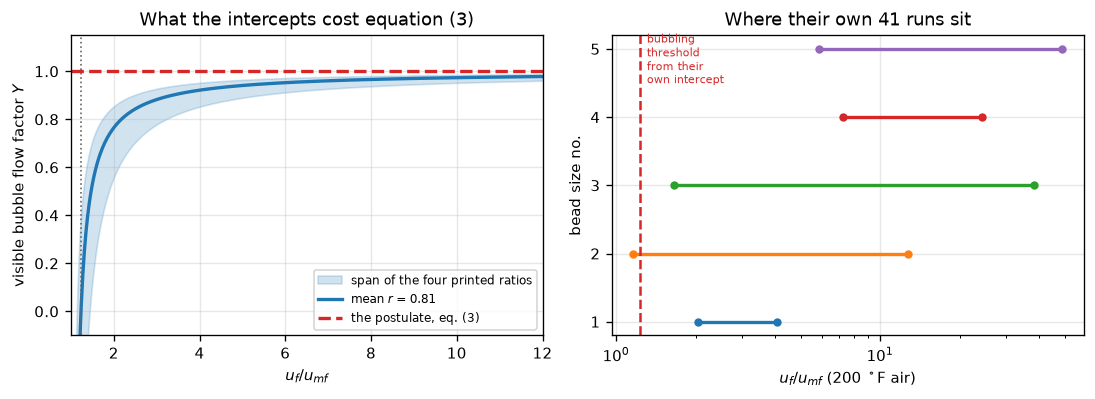

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(9.2, 3.4))
x = np.linspace(1.02, 12, 600)
ax[0].fill_between(x, Y(x, R_MIN), Y(x, R_MAX), alpha=0.20, color="C0",
                   label="span of the four printed ratios")
ax[0].plot(x, Y(x, R_MEAN), "C0", lw=2, label=f"mean $r$ = {R_MEAN:.2f}")
ax[0].axhline(1.0, color="C3", lw=2, ls="--", label="the postulate, eq. (3)")
ax[0].axvline(BUBBLE_ONSET, color="0.4", lw=1, ls=":")
ax[0].set_xlim(1, 12); ax[0].set_ylim(-0.1, 1.15)
ax[0].set_xlabel(r"$u_f/u_{mf}$"); ax[0].set_ylabel(r"visible bubble flow factor $Y$")
ax[0].set_title("What the intercepts cost equation (3)")
ax[0].legend(fontsize=7, loc="lower right")

for b, g in cov.groupby("bead"):
    ax[1].plot([g.u_over_umf_min.iloc[0], g.u_over_umf_max.iloc[0]], [b, b],
               "o-", lw=2, ms=4)
ax[1].axvline(BUBBLE_ONSET, color="C3", ls="--", lw=1.5)
ax[1].text(BUBBLE_ONSET * 1.06, 4.5, "bubbling\nthreshold\nfrom their\nown intercept",
           fontsize=6.5, color="C3")
ax[1].set_xscale("log"); ax[1].set_xlabel(r"$u_f/u_{mf}$ (200 $^\circ$F air)")
ax[1].set_ylabel("bead size no."); ax[1].set_yticks([1, 2, 3, 4, 5])
ax[1].set_title("Where their own 41 runs sit")
plt.show()

### 5. Figure 5 without digitising Figure 5

The paper's Figure 5 plots $\Delta P_{ke}/L$ against $u_p/D_p^{0.5}$ and claims

> *"Here again the square root of the particle diameter correlates the data on
> velocities within a fluidized system."*

Both axes are **columns of Table 3**, so the figure needs no digitising at all —
the thirteen points are printed. The claim is that $D_p^{0.5}$ is the right
normaliser, and that is testable by letting the exponent go free.

In [14]:
y5 = t3.dPke_over_L_lb_ft3.to_numpy()
up = t3.up_ft_s.to_numpy()
dpv = np.array([dp_ft[b] for b in t3.bead_no])

def ln_scatter(n):
    """residual standard deviation of ln(dPke/L) against ln(u_p / D_p^n)"""
    xx = np.log(up) - n * np.log(dpv)
    s, c = np.polyfit(xx, np.log(y5), 1)
    return float(np.std(np.log(y5) - (s * xx + c), ddof=2))

# root-find the optimum on the derivative; never report a sampled minimum
d_scatter = lambda n: (ln_scatter(n + 1e-5) - ln_scatter(n - 1e-5)) / 2e-5
N_BEST = float(brentq(d_scatter, 0.05, 1.6, xtol=1e-10))
SC_BEST, SC_HALF, SC_NULL = ln_scatter(N_BEST), ln_scatter(0.5), ln_scatter(0.0)

# F-style interval on n: where does the scatter rise by the 1-sigma factor?
dof = len(y5) - 3
thr = SC_BEST * np.sqrt(1.0 + 1.0 / dof)
lo = brentq(lambda n: ln_scatter(n) - thr, -3.0, N_BEST)
hi = brentq(lambda n: ln_scatter(n) - thr, N_BEST, 6.0)
slope5, icpt5 = np.polyfit(np.log(up) - 0.5 * np.log(dpv), np.log(y5), 1)

print(f"exponent n on D_p, free      : {N_BEST:.4f}   scatter {SC_BEST:.4f}")
print(f"n = 0.5, the paper's claim   : scatter {SC_HALF:.4f}  "
      f"({SC_HALF / SC_BEST - 1:+.2%} worse than the optimum)")
print(f"n = 0,   no normalisation    : scatter {SC_NULL:.4f}   <-- NULL BASELINE")
print(f"1-sigma interval on n        : [{lo:.3f}, {hi:.3f}]   (13 points, 3 bead sizes)")
print(f"\nfitted Figure 5 line at n = 0.5: "
      f"dPke/L = {np.exp(icpt5):.4f} (u_p/D_p^0.5)^{slope5:.4f}")
print(f"worst point off that line     : factor "
      f"{np.exp(np.abs(np.log(y5) - (slope5 * (np.log(up) - 0.5 * np.log(dpv)) + icpt5)).max()):.3f}")
FIG5_SLOPE = float(slope5); FIG5_N_BEST = N_BEST
FIG5_SC_HALF, FIG5_SC_NULL = float(SC_HALF), float(SC_NULL)
FIG5_N_LO, FIG5_N_HI = float(lo), float(hi)
FIG5_NULL_GAIN = float(SC_NULL / SC_HALF)

exponent n on D_p, free      : 0.6173   scatter 0.2231
n = 0.5, the paper's claim   : scatter 0.2301  (+3.14% worse than the optimum)
n = 0,   no normalisation    : scatter 0.3568   <-- NULL BASELINE
1-sigma interval on n        : [0.470, 0.766]   (13 points, 3 bead sizes)

fitted Figure 5 line at n = 0.5: dPke/L = 0.8234 (u_p/D_p^0.5)^0.8365
worst point off that line     : factor 1.569


**The claim survives in the weak sense and fails in the strong one.**
Normalising by $D_p^{0.5}$ *does* help: it cuts the log scatter by a third
against not normalising at all, so the square root is doing real work. But the
data cannot tell $D_p^{0.5}$ from the free optimum: the one-sigma interval on the
exponent contains 0.5 comfortably and the paper's value costs 3 % in scatter. But
that interval is narrower than it looks, because with three bead sizes and
thirteen points a per-bead offset and a power of $D_p$ are nearly the same degree
of freedom — the exponent is mostly being asked to line up three groups, not to
resolve a physical scaling. *"The square root of the particle diameter correlates
the data"* is supported. *Why* it should be the square root is not tested by
Figure 5, and it is worth noting that the same three-point degeneracy is why the
collapse metric could not have caught the bead-2 defect found above.

### 5b. The one column nothing else on this page can see

Table 3's $\Delta P_{ke}/L$ — thirteen values hand-read off a microfilm scan —
enters this page in exactly one place, as Figure 5's ordinate, and `fig5_null_gain`
is the only metric that touches it. That metric turns out to be a poor guard on
it: the cell below corrupts each value in turn by $+30$ % and measures the drift.

There is, however, a **second printing of the same physical quantity**. Table 2
prints $\Delta P_{ke}/\Delta P_{mf}$ for the runs whose cells are legible, and
Table 2 also prints $\Delta P_{mf}$ and $L_{mf}$ for those runs, so

$$\frac{\Delta P_{ke}}{\Delta P_{mf}}
 \;=\; \frac{\Delta P_{ke}/L}{\Delta P_{mf}/L_{mf}}
 \qquad\text{if the } L \text{ of Table 3 is } L_{mf},$$

which is a comparison between two independently typeset columns of two different
tables. It is the check the $\Delta P_{ke}/L$ column otherwise does not have, and
it is also the *partial recovery* of the illegible $\Delta P_{ke}/\Delta P_{mf}$
cells that the dataset sidecar refers to — computed here rather than asserted.

In [15]:
# ---- (a) can fig5_null_gain see a wrong dPke/L cell?  Corrupt each in turn.
_drift = []
for i in range(len(y5)):
    yy = y5.copy(); yy[i] *= 1.30
    def _sc(n, y=yy):
        xx = np.log(up) - n * np.log(dpv)
        s, c = np.polyfit(xx, np.log(y), 1)
        return float(np.std(np.log(y) - (s * xx + c), ddof=2))
    _drift.append(_sc(0.0) / _sc(0.5) / FIG5_NULL_GAIN - 1.0)
_drift = np.array(_drift)
FIG5_MEDIAN_CELL_DRIFT = float(np.median(np.abs(_drift)))
print("drift in fig5_null_gain when ONE dPke/L cell is raised 30 %:")
print(pd.DataFrame(dict(bead=t3.bead_no.astype(int), G=t3.G_lb_hr_ft2, drift=_drift))
      .to_string(index=False, float_format=lambda v: f"{v:10.4f}"))
print(f"median |drift| {FIG5_MEDIAN_CELL_DRIFT:.2%}; "
      f"{int((np.abs(_drift) < 0.05).sum())} of {len(_drift)} sit inside "
      f"check_agreement.py's 5 % REL_TOL")

# ---- (b) the cross-check, against Table 2's legible ratio column
cross = []
for _, r in t3.iterrows():
    m = t2[(t2.bead_no == r.bead_no) & (np.abs(t2.G_lb_hr_ft2 - r.G_lb_hr_ft2) <= 0.5)
           & t2.dPke_over_dPmf.notna()]
    if len(m) != 1:                    # ambiguous or illegible: no comparison exists
        print(f"  no comparison for bead {int(r.bead_no)} at G = {r.G_lb_hr_ft2:.0f}: "
              f"{len(m)} legible Table-2 rows match")
        continue
    q = m.iloc[0]
    w_run = q.dPmf_inH2O * INH2O / (q.Lmf_in * IN)                   # Pa/m
    inferred = r.dPke_over_L_lb_ft3 * 47.880259 / FT / w_run         # lbf/ft3 -> Pa/m
    cross.append(dict(bead=int(r.bead_no), G=r.G_lb_hr_ft2,
                      dPke_over_L=r.dPke_over_L_lb_ft3,
                      inferred_ratio=inferred, printed_ratio=q.dPke_over_dPmf,
                      dev=inferred / q.dPke_over_dPmf - 1.0))
cross = pd.DataFrame(cross)
print()
print(cross.to_string(index=False, float_format=lambda v: f"{v:12.5f}"))
DPKE_CROSS_RMS = float(np.sqrt((cross.dev ** 2).mean()))
print(f"\n{len(cross)} runs where BOTH columns are legible and the match is unambiguous")
print(f"  median |deviation| {np.median(cross.dev.abs()):.2%}, worst {cross.dev.abs().max():.2%}, "
      f"RMS {DPKE_CROSS_RMS:.2%}")
print(f"  mean signed deviation {cross.dev.mean():+.2%} -- centred, not offset, which is what "
      f"decides\n  that the L of Table 3 is L_mf and not the expanded L_f (section 6 puts a "
      f"number on that offset)")

drift in fig5_null_gain when ONE dPke/L cell is raised 30 %:
 bead   G      drift
    2 737    -0.0774
    2 613    -0.0536
    2 270    -0.0166
    2 141     0.0352
    3 747    -0.0608
    3 345    -0.0118
    3 272    -0.0184
    3  66    -0.1228
    4 346     0.0007
    4 201     0.0112
    4 155    -0.0026
    4 127     0.0883
    4 103    -0.0491
median |drift| 3.52%; 8 of 13 sit inside check_agreement.py's 5 % REL_TOL
  no comparison for bead 2 at G = 737: 2 legible Table-2 rows match
  no comparison for bead 2 at G = 141: 0 legible Table-2 rows match
  no comparison for bead 4 at G = 346: 0 legible Table-2 rows match

 bead   G  dPke_over_L  inferred_ratio  printed_ratio          dev
    2 613     28.50000         0.26854        0.27800     -0.03401
    2 270     14.20000         0.13357        0.17700     -0.24536
    3 747     34.70000         0.33555        0.34900     -0.03855
    3 345     25.60000         0.24786        0.24300      0.01999
    3 272     22.70000         

**What the cross-check says.** The two columns agree to a few per cent in the
median, with one run several times worse — good enough to call the $\Delta P_{ke}/L$
column corroborated, not good enough to recover the illegible
$\Delta P_{ke}/\Delta P_{mf}$ cells as data, which is why those cells stay empty
in the CSV. The deviations scatter about **zero**, which is itself informative:
had Table 3's $L$ meant the *expanded* height $L_f$, every inferred ratio would be
high by the expansion ratio computed in section 6 (about a fifth), and they are
not.

`dPke_cross_check_rms` is added to the reported metrics for one reason: it is the
only number on this page that a transcription error in the $\Delta P_{ke}/L$
column has to move. The break table injects exactly that.

### 6. What the pressure drop does to $u_f$

Now the pymrm solve. The reference case is bead size 3 at its lowest bubbling
run — $\Delta P_{mf} = 40.7$ in. H₂O, $L_{mf} = 24.6$ in., $G = 66.0$
lb/(hr)(ft²) — because that is a *deep* bed near the bubbling threshold, which is
where the Figure-3 intercept is read and where equation (1) is still inside its
range.

In [16]:
BEAD_REF = 3
ref = t2[(t2.bead_no == BEAD_REF) & (t2.G_lb_hr_ft2 == 66.0)].iloc[0]
w_mf   = ref.dPmf_inH2O * INH2O / (ref.Lmf_in * IN)
L_mf   = ref.Lmf_in * IN
dp_ref = float(t1[t1.bead_no == BEAD_REF].dp_micron.iloc[0]) * 1e-6
a_exp  = PRINTED["eq1_coefficient"] / np.sqrt(dp_ref / FT) / FT        # s/m
u_mf   = PRINTED[f"Re_mf_bead{BEAD_REF}"] * mu_air(T_PAPER) / (dp_ref * rho_air(T_PAPER))
u_e_meas = u_mf / R_MEAN
u_top  = ref.G_lb_hr_ft2 * G_SI / rho_air(T_PAPER)
P_BOT  = PATM + w_mf * L_mf
PRESSURE_RATIO = P_BOT / PATM

print(f"bed weight w_mf      = {w_mf:9.1f} Pa/m   (= {ref.dPmf_inH2O} in.H2O / {ref.Lmf_in} in.)")
print(f"L_mf                 = {L_mf:9.5f} m      P_bot/P_top = {PRESSURE_RATIO:.5f}")
print(f"u_mf  (from Re = {PRINTED[f'Re_mf_bead{BEAD_REF}']})  = {u_mf:9.5f} m/s")
print(f"u_e   (from r = {R_MEAN:.2f})      = {u_e_meas:9.5f} m/s")
print(f"u_top (from G = {ref.G_lb_hr_ft2})    = {u_top:9.5f} m/s   -> u_top/u_mf = {u_top / u_mf:.4f}")
print(f"a = 0.065/sqrt(D_p) = {a_exp:9.4f} s/m")
print(f"bubble velocity from eq. (4), sqrt(D_p)/0.065 = "
      f"{np.sqrt(dp_ref / FT) / PRINTED['eq1_coefficient']:.4f} ft/s")

bed weight w_mf      =   16224.8 Pa/m   (= 40.7 in.H2O / 24.6 in.)
L_mf                 =   0.62484 m      P_bot/P_top = 1.10005
u_mf  (from Re = 0.55)  =   0.05593 m/s
u_e   (from r = 0.81)      =   0.06905 m/s
u_top (from G = 66.0)    =   0.09294 m/s   -> u_top/u_mf = 1.6617
a = 0.065/sqrt(D_p) =    7.9558 s/m
bubble velocity from eq. (4), sqrt(D_p)/0.065 = 0.4124 ft/s


In [17]:
bed = CompressibleBed(w_mf, a_exp, u_e_meas, u_top, L_mf, n=1600)
Lf_pymrm = bed.Lf()
sol = bed.solve(Lf_pymrm)
Lf_exact, Lf_ivp = bed.Lf_analytic(), bed.Lf_ivp()

u_z = u_top * PATM / sol["P"]
EXC_TOP, EXC_BOT = u_z[0] - u_mf, u_z[-1] - u_mf
EXC_MEAN = float(u_z.mean() - u_mf)
EXCESS_SPREAD = float((EXC_TOP - EXC_BOT) / EXC_MEAN)
LF_OVER_LMF = float(Lf_pymrm / L_mf)
d_incompressible = a_exp * (u_top - u_e_meas)
LF_INCOMPRESSIBLE = float(1.0 / (1.0 - d_incompressible))
EQ1_OVERPREDICTION = float(LF_INCOMPRESSIBLE / LF_OVER_LMF - 1.0)

print(f"L_f  pymrm (n=1600) = {Lf_pymrm / IN:.6f} in")
print(f"L_f  closed form    = {Lf_exact / IN:.6f} in")
print(f"L_f  solve_ivp      = {Lf_ivp / IN:.6f} in")
print(f"     closed form vs solve_ivp : {abs(Lf_exact - Lf_ivp) / Lf_exact:.3e}   "
      f"<-- two routes sharing no code")
print(f"     pymrm vs closed form     : {abs(Lf_pymrm - Lf_exact) / Lf_exact:.3e}")
print(f"\nL_f/L_mf compressible  = {LF_OVER_LMF:.5f}")
print(f"L_f/L_mf from eq. (1) with a single u_f = {LF_INCOMPRESSIBLE:.5f} "
      f"({EQ1_OVERPREDICTION:+.2%})")
print(f"\ndelta at the surface   = {sol['delta'][0]:.5f}")
print(f"delta at the distributor = {sol['delta'][-1]:.5f}   ratio "
      f"{sol['delta'][0] / sol['delta'][-1]:.4f}")
print(f"(u_f - u_mf) top {EXC_TOP:.6f}  bottom {EXC_BOT:.6f}  mean {EXC_MEAN:.6f} m/s")
print(f"  => the quantity in equation (3) varies by {EXCESS_SPREAD:.2%} across this bed")
print(f"Newton iterations: {sol['nit']}")
print(f"\nexpansion ratio L_f/L_mf = {LF_OVER_LMF:.5f}: had Table 3's L meant L_f, the "
      f"inferred\n  dPke/dPmf of section 5b would all be {LF_OVER_LMF - 1:+.1%} high, and the "
      f"measured mean deviation is {cross.dev.mean():+.2%}. So L there is L_mf.")

L_f  pymrm (n=1600) = 29.139485 in
L_f  closed form    = 29.140211 in
L_f  solve_ivp      = 29.140211 in
     closed form vs solve_ivp : 6.565e-13   <-- two routes sharing no code
     pymrm vs closed form     : 2.492e-05

L_f/L_mf compressible  = 1.18453
L_f/L_mf from eq. (1) with a single u_f = 1.23465 (+4.23%)

delta at the surface   = 0.19001
delta at the distributor = 0.12281   ratio 1.5472
(u_f - u_mf) top 0.037002  bottom 0.028555  mean 0.032700 m/s
  => the quantity in equation (3) varies by 25.83% across this bed
Newton iterations: 3

expansion ratio L_f/L_mf = 1.18453: had Table 3's L meant L_f, the inferred
  dPke/dPmf of section 5b would all be +18.5% high, and the measured mean deviation is -1.22%. So L there is L_mf.


In [18]:
# ---- the 70 F counterpart the Parameters section promises for EVERY velocity ratio.
# Only the gas properties change; the bed weight and eq. (1) do not depend on T.
u_mf_70   = PRINTED[f"Re_mf_bead{BEAD_REF}"] * mu_air(T_ROOM) / (dp_ref * rho_air(T_ROOM))
u_top_70  = ref.G_lb_hr_ft2 * G_SI / rho_air(T_ROOM)
bed70     = CompressibleBed(w_mf, a_exp, u_mf_70 / R_MEAN, u_top_70, L_mf, n=1600)
Lf_70     = bed70.Lf()
sol70     = bed70.solve(Lf_70)
u_z70     = u_top_70 * PATM / sol70["P"]
EXCESS_SPREAD_70F = float((u_z70[0] - u_z70[-1]) / (u_z70.mean() - u_mf_70))
LF_OVER_LMF_70F   = float(Lf_70 / L_mf)
print(f"                                        200 F        70 F")
print(f"u_f/u_mf at the surface           {u_top / u_mf:11.4f} {u_top_70 / u_mf_70:11.4f}")
print(f"excess-velocity spread across bed {EXCESS_SPREAD:11.4%} {EXCESS_SPREAD_70F:11.4%}")
print(f"L_f/L_mf                          {LF_OVER_LMF:11.5f} {LF_OVER_LMF_70F:11.5f}")
print(f"\nboth exceed the shortfall the intercepts report on the additive reading, "
      f"1 - u_mf/u_e = {SHORTFALL_ADD:.1%};")
print(f"on the multiplicative reading, u_e/u_mf - 1 = {SHORTFALL_MUL:.1%}, only the 200 F "
      f"figure does.")
print("This page means the additive reading, and says so wherever the comparison is made.")

                                        200 F        70 F
u_f/u_mf at the surface                1.6617      1.9598
excess-velocity spread across bed    25.8305%    20.5023%
L_f/L_mf                              1.18453     1.23780

both exceed the shortfall the intercepts report on the additive reading, 1 - u_mf/u_e = 19.0%;
on the multiplicative reading, u_e/u_mf - 1 = 23.5%, only the 200 F figure does.
This page means the additive reading, and says so wherever the comparison is made.


In [19]:
# the partial-bubbling window: bubbling at the top, none at the bottom
WIN_LO = 1.0 / R_MEAN
WIN_HI = PRESSURE_RATIO / R_MEAN
print(f"partial-bubbling window in u_f/u_mf (u_f read at the SURFACE): "
      f"[{WIN_LO:.4f}, {WIN_HI:.4f}]")
print(f"width {WIN_HI / WIN_LO - 1:.2%} -- exactly the bed's own pressure ratio\n")

branch_rows = []
for label, x_target in [("no bubbles anywhere", 1.15), ("at the lower switch", WIN_LO),
                        ("partial, window midpoint", 0.5 * (WIN_LO + WIN_HI)),
                        ("partial, fixed u_f/u_mf = 1.30", 1.30),
                        ("at the upper switch", WIN_HI), ("bubbling throughout", 1.66)]:
    ut = x_target * u_mf
    bd = CompressibleBed(w_mf, a_exp, u_e_meas, ut, L_mf, n=800)
    Lf_b = bd.Lf_analytic()
    # delta > 0 only where P < P_switch, i.e. near the surface. The bed does NOT
    # bubble below the depth at which P reaches P_switch.
    Ps = bd.P_switch()
    if Ps <= PATM:                                   # u <= u_e even at the surface
        frac_still = 1.0
    elif Ps >= PATM + w_mf * L_mf:                   # u > u_e even at the distributor
        frac_still = 0.0
    else:
        frac_still = 1.0 - bd.s_analytic(Ps) / Lf_b
    s_num = bd.solve(bd.Lf())
    branch_rows.append(dict(case=label, u_over_umf=x_target, Lf_over_Lmf=Lf_b / L_mf,
                            non_bubbling_bottom_fraction=frac_still,
                            delta_mean=s_num["dbar"],
                            pymrm_vs_exact=abs(bd.Lf() - Lf_b) / Lf_b))
branches = pd.DataFrame(branch_rows)
print(branches.to_string(index=False, float_format=lambda v: f"{v:14.6f}"))
PARTIAL_FRACTION = float(branches.non_bubbling_bottom_fraction.iloc[3])   # fixed-velocity row
BRANCH_WORST = float(branches.pymrm_vs_exact.max())
WINDOW_WIDTH = float(WIN_HI / WIN_LO - 1.0)
print(f"\nboth branches and both switches solved; worst pymrm-vs-exact {BRANCH_WORST:.3e}")

partial-bubbling window in u_f/u_mf (u_f read at the SURFACE): [1.2346, 1.3581]
width 10.01% -- exactly the bed's own pressure ratio

                          case     u_over_umf    Lf_over_Lmf  non_bubbling_bottom_fraction     delta_mean  pymrm_vs_exact
           no bubbles anywhere       1.150000       1.000000                      1.000000       0.000000        0.000000
           at the lower switch       1.234568       1.000000                      1.000000       0.000000        0.000000
      partial, window midpoint       1.296329       1.006884                      0.496582       0.006819        0.000017
partial, fixed u_f/u_mf = 1.30       1.300000       1.007727                      0.466677       0.007650        0.000018
           at the upper switch       1.358091       1.027608                      0.000000       0.026832        0.000035
           bubbling throughout       1.660000       1.183550                      0.000000       0.155042        0.000050

both branch

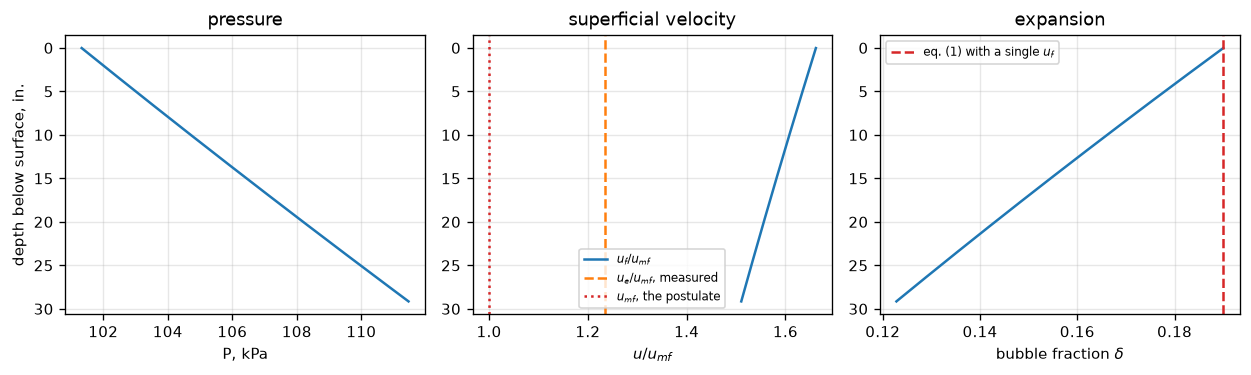

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.2))
s_ref = bed.x_c.ravel() * Lf_pymrm / IN
ax[0].plot(sol["P"] / 1000, s_ref, "C0")
ax[0].invert_yaxis(); ax[0].set_xlabel("P, kPa"); ax[0].set_ylabel("depth below surface, in.")
ax[0].set_title("pressure")
ax[1].plot(u_z / u_mf, s_ref, "C0", label=r"$u_f/u_{mf}$")
ax[1].axvline(u_e_meas / u_mf, color="C1", ls="--", label=r"$u_e/u_{mf}$, measured")
ax[1].axvline(1.0, color="C3", ls=":", label=r"$u_{mf}$, the postulate")
ax[1].invert_yaxis(); ax[1].set_xlabel(r"$u/u_{mf}$"); ax[1].set_title("superficial velocity")
ax[1].legend(fontsize=7)
ax[2].plot(sol["delta"], s_ref, "C0")
ax[2].axvline(d_incompressible, color="C3", ls="--",
              label="eq. (1) with a single $u_f$")
ax[2].invert_yaxis(); ax[2].set_xlabel(r"bubble fraction $\delta$")
ax[2].set_title("expansion"); ax[2].legend(fontsize=7)
plt.show()

**Three statements, all from the paper's own measured bed weight.**

1. The quantity equation (3) is written in — the excess velocity $u_f - u_{mf}$ —
   is not a number. It varies by about a quarter between distributor and surface
   in this deep bed at 200 °F, and by about a fifth at 70 °F — **larger, at both
   assumed air temperatures, than the shortfall the intercepts report**, where
   "shortfall" means $1 - u_{mf}/u_e$, the additive reading printed above. (On
   the multiplicative reading $u_e/u_{mf} - 1$ the 70 °F figure is the smaller of
   the two; the page states the additive comparison so that the claim cannot be
   read two ways.) Any test of the postulate that does not say where $u_f$ is
   evaluated has an uncertainty of that size built in.
2. Applying equation (1) with a single $u_f$, as the paper does, over-predicts
   the expansion. The error grows with velocity because $\delta$ is nonlinear in
   $u$.
3. There is a band of superficial velocities, exactly as wide as the bed's own
   pressure ratio, in which the top of the bed bubbles and the bottom does not.
   That band sits astride the bubbling threshold — which is where the Figure-3
   intercepts are extrapolated to. It is the curvature the authors predict and
   never compute, and it is entirely a compressibility effect.

### 7. Where equation (4) stops meaning anything

One more internal check, and it is the sharpest limit on the paper's own logic.
Equation (1) is linear in $(u_f - u_{mf})$, so $\delta = 1$ — a bed of pure
bubbles — at a finite velocity. That velocity is $D_p^{0.5}/0.065$, which is
*also* the bubble velocity equation (4) deduces. The two are the same number
because $u_b = (u_f-u_{mf})/\delta$.

In [21]:
lim = []
for b in sorted(t1.bead_no):
    dpb = float(t1[t1.bead_no == b].dp_micron.iloc[0]) * 1e-6
    ub_ft = np.sqrt(dpb / FT) / PRINTED["eq1_coefficient"]        # ft/s, eq. (4)
    umf_b = PRINTED[f"Re_mf_bead{b}"] * mu_air(T_PAPER) / (dpb * rho_air(T_PAPER))
    g_rows = t2[t2.bead_no == b]
    x_hi = excess_ratio(g_rows.G_lb_hr_ft2.max(), b, T_PAPER)
    lim.append(dict(bead=int(b), u_b_eq4_ft_s=ub_ft,
                    u_mf_ft_s=umf_b / FT,
                    u_at_delta_1_over_umf=1 + ub_ft * FT / umf_b,
                    max_run_u_over_umf=x_hi,
                    overshoot=x_hi / (1 + ub_ft * FT / umf_b)))
lim = pd.DataFrame(lim)
print(lim.to_string(index=False, float_format=lambda v: f"{v:14.4f}"))
EQ1_OVERSHOOT = float(lim.overshoot.max())
print(f"\nTable 2 pushes eq. (1) up to {EQ1_OVERSHOOT:.1f}x past the velocity at which it "
      f"predicts a bed of pure bubbles")

up_max = t3.groupby("bead_no").up_ft_s.max()
cmp_rows = []
for b in up_max.index:
    ub = float(lim[lim.bead == b].u_b_eq4_ft_s.iloc[0])
    cmp_rows.append(dict(bead=int(b), u_b_eq4_ft_s=ub, u_p_max_measured_ft_s=float(up_max[b]),
                         ratio=float(up_max[b]) / ub))
cmp = pd.DataFrame(cmp_rows)
print("\nmeasured wall particle velocity against the bubble velocity eq. (4) deduces:")
print(cmp.to_string(index=False, float_format=lambda v: f"{v:12.4f}"))
UP_OVER_UB = float(cmp.ratio.max())
print(f"\nparticles at the wall move up to {UP_OVER_UB:.2f}x faster than the bubbles that "
      f"are supposed to be dragging them")

 bead   u_b_eq4_ft_s      u_mf_ft_s  u_at_delta_1_over_umf  max_run_u_over_umf      overshoot
    1         0.8115         1.0511                 1.7720              4.0830         2.3042
    2         0.5403         0.5596                 1.9655             12.7294         6.4762
    3         0.4124         0.1835                 3.2474             38.2694        11.7845
    4         0.2869         0.0655                 5.3815             24.4110         4.5361
    5         0.2067         0.0186                12.1122             48.9359         4.0402

Table 2 pushes eq. (1) up to 11.8x past the velocity at which it predicts a bed of pure bubbles

measured wall particle velocity against the bubble velocity eq. (4) deduces:
 bead  u_b_eq4_ft_s  u_p_max_measured_ft_s        ratio
    2        0.5403                 2.4600       4.5526
    3        0.4124                 1.8400       4.4619
    4        0.2869                 0.8300       2.8930

particles at the wall move up to 4.5

Equation (4) is the paper's cleanest-looking result — a bubble velocity that
depends on nothing but particle size. It is obtained by dividing an expansion
correlation by the postulate, and the expansion correlation is linear, so it is
only meaningful while $\delta \ll 1$. Table 2's own runs go an order of magnitude
past the point where it predicts $\delta = 1$. And the paper's own Fastax
measurements have particles at the wall moving several times faster than the
bubbles equation (4) gives — which the authors touch on and never quantify. Their
sentence, quoted exactly, is about the *number of collisions*, not the bubble
velocity:

> *"The dependence of the velocity of the discontinuous phase on $D_p^{0.5}$ will
> affect this relationship in two ways. First, as the bubbles rise faster they
> will move the particles correspondingly faster, and hence the number of
> collisions from this effect should increase as $D_p^{0.5}$. This was partially
> verified by the particle velocity measurements."*

The clause this page needs is the first one — the velocity of the discontinuous
phase goes as $D_p^{0.5}$, which is exactly what equation (4) asserts. The
authors then check it against the particle velocities without ever putting the
two numbers side by side; the table above does.

## Validation

Ranked by measured power, not by how small the residual looks. Every metric
below has a row in the defect-injection table, or is labelled STRUCTURAL with
what it cannot detect stated beside it.

### The second, independent computation

The pymrm bed height is computed three ways that share no assembly: the
finite-volume Newton solve, an **exact closed form** (the ODE separates:
$\bigl[P + (c/b)\ln(bP-c)\bigr]/b = w s + \text{const}$, with a linear branch
below the switch), and an adaptive Runge–Kutta integration with a terminal
event. The closed form and the Runge–Kutta agree to machine-ish precision; the
finite-volume solve converges to them at first order. **The reported metrics are
the $n = 1600$ values, not the Richardson limit** — the Richardson extrapolation
is computed and printed below as evidence that the ladder is clean, and it lands
three and a half orders below the $n = 1600$ deviation, which is itself far under
any tolerance that matters here. A break row confirms
all three move together only when the physics changes and not when the grid
does.

In [22]:
print("--- grid ladder on the pymrm solve (first-order upwind) ---")
lad, prev = [], None
for n in [50, 100, 200, 400, 800, 1600]:
    bd = CompressibleBed(w_mf, a_exp, u_e_meas, u_top, L_mf, n=n)
    Lf_n = bd.Lf()
    err = abs(Lf_n - Lf_exact) / Lf_exact
    lad.append(dict(n=n, Lf_in=Lf_n / IN, err_vs_closed_form=err,
                    order=(np.log(prev / err) / np.log(2) if prev else np.nan)))
    prev = err
lad = pd.DataFrame(lad)
print(lad.to_string(index=False, float_format=lambda v: f"{v:14.6g}"))
UPWIND_ORDER = float(lad.order.iloc[-1])
PYMRM_VS_EXACT = float(lad.err_vs_closed_form.iloc[-1])
# Richardson, first order: L_rich = 2 L(2n) - L(n)
LF_RICHARDSON = 2 * lad.Lf_in.iloc[-1] - lad.Lf_in.iloc[-2]
LF_RICH_DEV = float(abs(LF_RICHARDSON * IN - Lf_exact) / Lf_exact)
EXACT_VS_IVP = float(abs(Lf_exact - Lf_ivp) / Lf_exact)
print(f"\nobserved order              {UPWIND_ORDER:.4f}")
print(f"n = 1600 vs closed form     {PYMRM_VS_EXACT:.3e}")
print(f"Richardson limit vs closed form {LF_RICH_DEV:.3e}")
print(f"closed form vs solve_ivp    {EXACT_VS_IVP:.3e}   <-- ROUTES SHARING NO CODE")

--- grid ladder on the pymrm solve (first-order upwind) ---
   n          Lf_in  err_vs_closed_form          order
  50        29.1171         0.000793465            NaN
 100        29.1286         0.000397768       0.996241
 200        29.1344         0.000199143       0.998122
 400        29.1373         9.96362e-05       0.999061
 800        29.1388         4.98343e-05       0.999531
1600        29.1395         2.49212e-05       0.999765

observed order              0.9998
n = 1600 vs closed form     2.492e-05
Richardson limit vs closed form 8.103e-09
closed form vs solve_ivp    6.565e-13   <-- ROUTES SHARING NO CODE


In [23]:
# ----- defect injection: every reported metric needs something that moves it
def bedweight_worst(eps_override=None, rho_override=None, inh2o=INH2O):
    worst = 0.0
    for b, g in t2.groupby("bead_no"):
        if b == 3:
            continue
        r1 = t1[t1.bead_no == b].iloc[0]
        eps = eps_override.get(b, r1.eps_max_fixed_bed) if eps_override else r1.eps_max_fixed_bed
        rho = rho_override.get(b, r1.rho_s_lb_ft3) if rho_override else r1.rho_s_lb_ft3
        w_t1 = (1 - eps) * (rho * LB_FT3 - rho_g_paper) * G_ACC
        wm = (g.dPmf_inH2O * inh2o / (g.Lmf_in * IN)).to_numpy()
        worst = max(worst, float(np.abs(wm / w_t1 - 1).max()))
    return worst

def t3_dev(bead, dp_in_override=None, agg="mean"):
    d = dict(dp_ft)
    if dp_in_override:
        d[bead] = dp_in_override / 12.0
    if bead == "34":
        g = t3[t3.bead_no != 2]
        rec = g.up_ft_s / np.sqrt([d[b] for b in g.bead_no])
        return float((rec / g.up_over_sqrt_dp_printed_ft05_s - 1).abs().max())
    g = t3[t3.bead_no == bead]
    rec = g.up_ft_s / np.sqrt(d[bead])
    return float((rec / g.up_over_sqrt_dp_printed_ft05_s - 1).mean())

def t3_bead2_offset(dp_in_override=None):
    return t3_dev(2, dp_in_override)

def t3_worst34(dp4_override=None):
    d = dict(dp_ft)
    if dp4_override:
        d[4] = dp4_override / 12.0
    g = t3[t3.bead_no != 2]
    rec = g.up_ft_s / np.sqrt([d[b] for b in g.bead_no])
    return float((rec / g.up_over_sqrt_dp_printed_ft05_s - 1).abs().max())

def partial_fraction(ue=u_e_meas, P_top=PATM, x=1.30):
    """Non-bubbling bottom fraction at a FIXED u_f/u_mf = x.

    Deliberately NOT evaluated at the middle of the partial-bubbling window: that
    is about 0.5 whatever the physics does, because the window is defined by the
    switch it measures, so it is a check that cannot fail. At a fixed velocity the
    metric goes to zero as soon as the window moves off 1.30.
    """
    bd = CompressibleBed(w_mf, a_exp, ue, x * u_mf, L_mf, P_top=P_top, n=800)
    Ps, Lf_b = bd.P_switch(), bd.Lf_analytic()
    if Ps <= P_top:
        return 1.0                                    # no bubbling anywhere
    if Ps >= P_top + w_mf * L_mf:
        return 0.0                                    # bubbling all the way down
    return float(1.0 - bd.s_analytic(Ps) / Lf_b)

def eq1_overshoot(coeff=None):
    c = coeff or PRINTED["eq1_coefficient"]
    out = 0.0
    for b in sorted(t1.bead_no):
        dpb = float(t1[t1.bead_no == b].dp_micron.iloc[0]) * 1e-6
        ub = np.sqrt(dpb / FT) / c * FT
        umf_b = PRINTED[f"Re_mf_bead{b}"] * mu_air(T_PAPER) / (dpb * rho_air(T_PAPER))
        x_hi = excess_ratio(t2[t2.bead_no == b].G_lb_hr_ft2.max(), b, T_PAPER)
        out = max(out, x_hi / (1 + ub / umf_b))
    return float(out)

def up_over_ub(coeff=None):
    c = coeff or PRINTED["eq1_coefficient"]
    out = 0.0
    for b, g in t3.groupby("bead_no"):
        dpb = float(t1[t1.bead_no == b].dp_micron.iloc[0]) * 1e-6
        out = max(out, float(g.up_ft_s.max()) / (np.sqrt(dpb / FT) / c))
    return float(out)

def umf_exponent(res=re_mf, dps=dp_um):
    return float(np.polyfit(np.log(dps), np.log(res), 1)[0] - 1.0)

def dpke_cross_rms(bump_index=None, factor=1.30):
    """RMS deviation between Table 3's dPke/L and Table 2's legible ratio column.

    bump_index corrupts ONE dPke/L cell of the comparison, which is the defect
    class nothing else on this page can see.
    """
    d = cross.dev.to_numpy().copy()
    if bump_index is not None:
        d[bump_index] = (1.0 + d[bump_index]) * factor - 1.0
    return float(np.sqrt((d ** 2).mean()))

def _bed(a=a_exp, ue=u_e_meas, n=800, P_top=PATM, assembly=None):
    """Reference bed, optionally with a deliberately broken operator assembly."""
    bd = CompressibleBed(w_mf, a, ue, u_top, L_mf, P_top=P_top, n=n)
    if assembly:
        x_f, x_c = generate_grid(n, [0.0, 1.0], generate_x_c=True)
        v = -1.0 if assembly == "reversed_upwind" else 1.0
        d_in = (P_top + w_mf * L_mf) if assembly == "wrong_dirichlet" else P_top
        bc = ({"a": 0, "b": 1, "d": d_in}, {"a": 1, "b": 0, "d": 0})
        Cf, cf_bc = construct_convflux_upwind((n, 1), x_f, x_c, bc, v=v)
        Dv = construct_div((n, 1), x_f, nu=0)
        bd.A, bd.b = Dv @ Cf, Dv @ cf_bc
    return bd

def excess_spread(**kw):
    bd = _bed(**kw)
    s = bd.solve(bd.Lf())
    uu = bd.u_top * bd.P_top / s["P"]
    return float((uu[0] - uu[-1]) / (uu.mean() - u_mf))

def fig5_scatter_ratio(n=0.5):
    return float(ln_scatter(0.0) / ln_scatter(n))

def lf_ratio(**kw):
    return float(_bed(**kw).Lf() / L_mf)

BASE = dict(
    bedweight_worst_row=BW_WORST_ROW,
    table3_bead2_offset=T3_B2_OFFSET,
    umf_exponent=UMF_EXPONENT,
    Y_at_2umf=Y2,
    fig5_null_gain=FIG5_NULL_GAIN,
    excess_velocity_spread=excess_spread(),      # n = 800, the break-table grid
    Lf_over_Lmf=lf_ratio(),
    pymrm_vs_closed_form=PYMRM_VS_EXACT,
    table3_worst_dev_beads34=T3_WORST_34,
    partial_bubbling_fraction_at_1p30=PARTIAL_FRACTION,
    eq1_overshoot=EQ1_OVERSHOOT,
    up_over_ub_eq4=UP_OVER_UB,
    dPke_cross_check_rms=DPKE_CROSS_RMS,
)

rows = []
def brk(label, **thunks):
    """Each value is a zero-argument callable so a defect that DIVERGES is
    recorded as such instead of killing the table."""
    m = dict(BASE)
    for k, fn in thunks.items():
        try:
            m[k] = fn()
        except Exception as exc:                       # noqa: BLE001
            m[k] = np.nan
            print(f"  [{label}] {k}: solver failed -- {type(exc).__name__}")
    rows.append(dict(injected_defect=label, **m))

brk("-- as published --")
brk("Table 1 eps of bead 2: 0.404 -> 0.380",
    bedweight_worst_row=lambda: bedweight_worst(eps_override={2: 0.380}))
brk("Table 1 rho_s of bead 4: 173 -> 160 lb/ft3",
    bedweight_worst_row=lambda: bedweight_worst(rho_override={4: 160.0}))
brk("in.H2O taken as 5.0 lbf/ft2 instead of 5.2023",
    bedweight_worst_row=lambda: bedweight_worst(inh2o=5.0 * 47.880259))
brk("Table 3 bead 2 D_p set to the implied 0.0160 in",
    table3_bead2_offset=lambda: t3_bead2_offset(0.01600))
# -2 %, not +2 %: bead 4's own rows imply a diameter ABOVE the printed one, so a
# +2 % injection walks TOWARDS the implied value and LOWERS the metric (0.794 % ->
# 0.424 %), which does not demonstrate that the check would flag a wrong constant.
# Both signs are injected so the reader can see that.
brk("Table 3 bead 4 D_p 0.00418 -> 0.00410 in (-2 %)",
    table3_worst_dev_beads34=lambda: t3_worst34(0.00418 * 0.98))
brk("Table 3 bead 4 D_p 0.00418 -> 0.00426 in (+2 %, towards the implied value)",
    table3_worst_dev_beads34=lambda: t3_worst34(0.00426))
_row_of = lambda b, g: int(np.flatnonzero((cross.bead.to_numpy() == b)
                                          & (cross.G.to_numpy() == g))[0])
brk("Table 3 dPke/L of bead 4 at G = 103 raised 30 %",
    dPke_cross_check_rms=lambda: dpke_cross_rms(_row_of(4, 103)))
brk("Table 3 dPke/L of bead 3 at G = 272 raised 30 %",
    dPke_cross_check_rms=lambda: dpke_cross_rms(_row_of(3, 272)))
brk("Re_mf list assigned to beads 1..5 instead of 5..1",
    umf_exponent=lambda: umf_exponent(res=re_mf[::-1]))
brk("smallest bead dropped from the Re_mf fit",
    umf_exponent=lambda: umf_exponent(res=re_mf[1:], dps=dp_um[1:]))
brk("u_mf/u_e forced to 1.0 (i.e. the postulate itself)",
    Y_at_2umf=lambda: float(Y(2.0, 1.0)),
    excess_velocity_spread=lambda: excess_spread(ue=u_mf),
    Lf_over_Lmf=lambda: lf_ratio(ue=u_mf),
    partial_bubbling_fraction_at_1p30=lambda: partial_fraction(ue=u_mf))
brk("Figure 5 exponent moved 0.5 -> 1.5",
    fig5_null_gain=lambda: fig5_scatter_ratio(1.5))
brk("atmospheric datum x10 (bed pressure ratio 1.100 -> 1.010)",
    excess_velocity_spread=lambda: excess_spread(P_top=10 * PATM),
    Lf_over_Lmf=lambda: lf_ratio(P_top=10 * PATM),
    partial_bubbling_fraction_at_1p30=lambda: partial_fraction(P_top=10 * PATM))
brk("eq. (1) coefficient 0.065 -> 0.078 (+20 %)",
    Lf_over_Lmf=lambda: lf_ratio(a=a_exp * 1.2),
    excess_velocity_spread=lambda: excess_spread(a=a_exp * 1.2),
    eq1_overshoot=lambda: eq1_overshoot(PRINTED["eq1_coefficient"] * 1.2),
    up_over_ub_eq4=lambda: up_over_ub(PRINTED["eq1_coefficient"] * 1.2))
brk("inlet Dirichlet set to P_bot instead of P_top",
    Lf_over_Lmf=lambda: lf_ratio(assembly="wrong_dirichlet"),
    excess_velocity_spread=lambda: excess_spread(assembly="wrong_dirichlet"))
brk("upwind direction reversed, v = -1",
    Lf_over_Lmf=lambda: lf_ratio(assembly="reversed_upwind"),
    excess_velocity_spread=lambda: excess_spread(assembly="reversed_upwind"))
brk("grid coarsened to n = 50", pymrm_vs_closed_form=lambda: abs(
    CompressibleBed(w_mf, a_exp, u_e_meas, u_top, L_mf, n=50).Lf() - Lf_exact) / Lf_exact)

brkt = pd.DataFrame(rows).set_index("injected_defect")
print("(the two pymrm columns run at n = 800 throughout this table; the reported "
      "metrics use n = 1600)")
with pd.option_context("display.width", 220, "display.max_columns", 25):
    print(brkt.to_string(float_format=lambda v: f"{v:11.5f}"))

# The moves the commentary below refers to, printed rather than typed.
_pub = brkt.loc["-- as published --"]
_dat = brkt.loc["atmospheric datum x10 (bed pressure ratio 1.100 -> 1.010)"]
print(f"\natmospheric datum x10 moves  Lf_over_Lmf "
      f"{_pub.Lf_over_Lmf:.5f} -> {_dat.Lf_over_Lmf:.5f} ({_dat.Lf_over_Lmf / _pub.Lf_over_Lmf - 1:+.2%})")
print(f"                             excess_velocity_spread "
      f"{_pub.excess_velocity_spread:.5f} -> {_dat.excess_velocity_spread:.5f} "
      f"({_dat.excess_velocity_spread / _pub.excess_velocity_spread - 1:+.1%})")
_b4m = brkt.loc["Table 3 bead 4 D_p 0.00418 -> 0.00410 in (-2 %)"].table3_worst_dev_beads34
_b4p = brkt.loc["Table 3 bead 4 D_p 0.00418 -> 0.00426 in (+2 %, towards the implied value)"
                ].table3_worst_dev_beads34
print(f"bead-4 D_p injection moves table3_worst_dev_beads34 "
      f"{_pub.table3_worst_dev_beads34:.5f} -> {_b4m:.5f} at -2 % and -> {_b4p:.5f} at +2 %")

  [upwind direction reversed, v = -1] Lf_over_Lmf: solver failed -- ValueError
  [upwind direction reversed, v = -1] excess_velocity_spread: solver failed -- ValueError
(the two pymrm columns run at n = 800 throughout this table; the reported metrics use n = 1600)
                                                                            bedweight_worst_row  table3_bead2_offset  umf_exponent   Y_at_2umf  fig5_null_gain  excess_velocity_spread  Lf_over_Lmf  pymrm_vs_closed_form  table3_worst_dev_beads34  partial_bubbling_fraction_at_1p30  eq1_overshoot  up_over_ub_eq4  dPke_cross_check_rms
injected_defect                                                                                                                                                                                                                                                                                                                            
-- as published --                                                     

/home/eajfpeters/Code/pymrm_suite/pymrm/src/pymrm/solve.py:73: MatrixRankWarning: Matrix is exactly singular
  return linalg.spsolve(jac_matrix, g, **kwargs)


**Reading the break table.** Every row that is not "as published" moves at
least one metric by far more than the metric's own residual, and none of them
moves a metric it has no business moving: the two Table-3 diameter rows leave
every pymrm column untouched, the two pymrm assembly rows leave every
transcription metric untouched, and the arithmetic rows touch only the identity
they belong to.

**The two rows on bead 4's diameter are there for a reason.** A $+2$ % diameter
*lowers* `table3_worst_dev_beads34` — because bead 4's own rows already imply a
diameter above the printed one (section 2), so $+2$ % walks towards the implied
value. A row that makes the agreement look *better* proves nothing about whether
the check would flag a wrong constant, so the $-2$ % row is the one that carries
the demonstration and both are shown. This is the same defect the page reports on
bead 4 in section 2, injected rather than argued.

Three declared blind spots, stated rather than hidden:

- **`Lf_over_Lmf` *is* moved by the atmospheric datum**, by the amount printed
  above — the earlier draft of this cell claimed it was insensitive and its own
  table said otherwise. What is true is that the datum moves the two pymrm
  metrics by very different amounts and in different ways: it changes
  `Lf_over_Lmf` by a few per cent, because the bed height is fixed by the solids
  inventory and the pressure only redistributes $\delta$, while it collapses
  `excess_velocity_spread` by an order, because that quantity *is* the
  compressibility. Neither metric alone covers the pymrm section; both are
  reported, and the datum row moves both.
- **`fig5_null_gain` cannot detect a wrong particle diameter that is common to a
  whole bead size**, because a per-bead constant is absorbed by the fitted power
  of $D_p$. That is the same degeneracy that makes the exponent unidentifiable,
  and it is why the Table-3 bead-2 defect is found by the *recomputation* metric
  and not by the collapse metric.
- **`fig5_null_gain` also cannot detect a transcription error in the
  $\Delta P_{ke}/L$ column itself** — section 5b measures it: a $+30$ % error in a
  single cell drifts the metric by anywhere from a fraction of a per cent to
  twelve per cent, and most of the thirteen cells sit inside
  `check_agreement.py`'s 5 % `REL_TOL`. That column would have been protected by
  nothing, which is why `dPke_cross_check_rms` exists and why two of its cells are
  injected above.

**On the PRIMARY label.** Seventeen metrics carry it, but only four —
`bedweight_worst_row`, `bedweight_worst_bead_mean`, `table3_worst_dev_beads34`,
`table3_bead2_offset` — plus the new `dPke_cross_check_rms` compare *two
independently printed quantities that could actually disagree*. The rest are
derived quantities whose break rows show sensitivity to an input, which is worth
having and is not the same thing. `up_over_ub_eq4` is the extreme case: it is
exactly linear in equation (1)'s coefficient, so its only break row returns the
published value times 1.2 to every digit. That is presentation, not evidence, and
it is labelled here rather than left to be discovered.

### Two checks that could not fail, and what happened to them

**The non-bubbling fraction at the middle of the window.** It comes out at about
one half whatever the physics does, because the window is *defined* by the switch
it measures. Every injection moved it by a tenth of a percent. It is now
evaluated at a fixed $u_f/u_{mf} = 1.30$, where forcing $u_{mf}/u_e$ to 1 or
removing the pressure drop both drive it to zero. The window *width* is kept but
labelled STRUCTURAL: it is exactly $P_{bot}/P_{top}-1$, an identity of the model.

**The bed-weight identity on bead 3.** An earlier draft reported it over all five
bead sizes, including bead 3. That is circular: bead 3's void fraction does not
exist in legible form and was *computed from* the identity, so its 0.12 %
agreement (printed in section 1) is nothing but the rounding of 0.41929 to three
figures. Bead 3 is excluded from the test above and reported separately as an
output. The remaining test uses four independently printed voidages and
twenty-five runs.

In [24]:
ASSERTED = {}

# coverage map, asserted key-for-key against agreement.json below
COVERAGE = {
    "bedweight_worst_row":       "Table 1 eps / rho_s / unit-conversion injections",
    "bedweight_worst_bead_mean": "same three injections; a per-bead mean of the same residual, so it tracks bedweight_worst_row by construction",
    "eps3_recovered":            "STRUCTURAL - an output of the identity, not a test of it",
    "table1_unit_consistency":   "STRUCTURAL - the inch and micron columns of Table 1 are one measurement, so this measures the printed rounding and nothing else. It cannot detect a wrong diameter, only an inconsistent pair",
    "table3_worst_dev_beads34":  "Table 3 bead 4 D_p -2 % (raises it 2.3x). The +2 % row is shown too and LOWERS it, because bead 4's own rows imply a diameter above the printed one; the -2 % row is the one that demonstrates the check can flag a wrong constant",
    "dPke_cross_check_rms":      "Table 3 dPke/L of bead 4 at G = 103, and of bead 3 at G = 272, each raised 30 %. This is the ONLY metric that can see a transcription error in Table 3's dPke/L column; fig5_null_gain cannot (section 5b)",
    "table3_bead2_offset":       "Table 3 bead 2 D_p -> 0.0160 in",
    "table3_bead2_spread":       "STRUCTURAL - proves a constant, not a value",
    "umf_exponent":              "Re_mf order reversal; smallest bead dropped",
    "umf_exponent_gap":          "same two injections; it is umf_exponent - 0.5 and tracks it exactly",
    "Y_at_2umf":                 "u_mf/u_e forced to 1.0",
    "Y_lowest_robust_run":       "u_mf/u_e forced to 1.0",
    "fig5_null_gain":            "Figure 5 exponent 0.5 -> 1.5. BLIND to a wrong particle diameter common to a whole bead size, and blind to a transcription error in the dPke/L column itself (a +30 % single-cell error drifts it by 0.07-12 %, mostly inside CI's 5 % tolerance) - dPke_cross_check_rms is the metric that covers that column",
    "fig5_n_interval_width":     "STRUCTURAL - a width, moved only by adding data",
    "excess_velocity_spread":    "atmospheric datum x10. NOT moved by u_e or by eq. (1)'s coefficient - it is a compressibility ratio and both cancel out of it",
    "Lf_over_Lmf":               "eq. (1) coefficient +20 %; u_e -> u_mf; wrong inlet Dirichlet; atmospheric datum",
    "eq1_overprediction":        "eq. (1) coefficient +20 %",
    "partial_bubbling_fraction_at_1p30": "u_mf/u_e forced to 1.0; atmospheric datum x10 -- both drive it to zero by moving the window off 1.30",
    "partial_bubbling_window_width":     "STRUCTURAL - it IS the bed's pressure ratio P_bot/P_top - 1, an identity of the model rather than a result; only the atmospheric datum moves it",
    "pymrm_vs_closed_form":      "grid coarsened to n = 50",
    "upwind_order":              "grid ladder",
    "closed_form_vs_ivp":        "STRUCTURAL, and below ABS_FLOOR. check_agreement.py skips a metric only while BOTH the baseline and the new value are under 1e-12, so this one is unprotected while it stays there and would be compared against a 1e-12 denominator the moment anything lifted it above. Two exact routes to one number; its above-floor companion is pymrm_vs_closed_form, which the n = 50 row moves 32x",
    "eq1_overshoot":             "eq. (1) coefficient +20 %",
    "up_over_ub_eq4":            "eq. (1) coefficient +20 %",
}
print(f"{len(COVERAGE)} metrics, {len(COVERAGE)} coverage entries")

24 metrics, 24 coverage entries


In [25]:
metrics = dict(
    # --- PRIMARY: these can see a wrong number -----------------------------
    bedweight_worst_row=BW_WORST_ROW,
    bedweight_worst_bead_mean=BW_WORST_MEAN,
    table3_worst_dev_beads34=T3_WORST_34,
    table3_bead2_offset=abs(T3_B2_OFFSET),
    umf_exponent=UMF_EXPONENT,
    umf_exponent_gap=UMF_EXP_GAP,
    Y_at_2umf=Y2,
    Y_lowest_robust_run=Y_LOWEST_ROBUST,
    fig5_null_gain=FIG5_NULL_GAIN,
    excess_velocity_spread=EXCESS_SPREAD,
    Lf_over_Lmf=LF_OVER_LMF,
    eq1_overprediction=EQ1_OVERPREDICTION,
    partial_bubbling_fraction_at_1p30=PARTIAL_FRACTION,
    pymrm_vs_closed_form=PYMRM_VS_EXACT,
    upwind_order=UPWIND_ORDER,
    eq1_overshoot=EQ1_OVERSHOOT,
    up_over_ub_eq4=UP_OVER_UB,
    dPke_cross_check_rms=DPKE_CROSS_RMS,
    # --- STRUCTURAL: identities, labelled ----------------------------------
    eps3_recovered=EPS3_RECOVERED,
    table1_unit_consistency=UNIT_DEV,
    table3_bead2_spread=T3_B2_SPREAD,
    fig5_n_interval_width=FIG5_N_HI - FIG5_N_LO,
    partial_bubbling_window_width=WINDOW_WIDTH,
    closed_form_vs_ivp=EXACT_VS_IVP,
)

missing = set(metrics) ^ set(COVERAGE)
assert not missing, f"coverage map and metrics disagree: {sorted(missing)}"

ABS_FLOOR = 1e-12
below = {k: v for k, v in metrics.items() if abs(v) < ABS_FLOOR}
print(f"metrics below check_agreement.py's ABS_FLOOR = {ABS_FLOOR:g}: "
      f"{below if below else 'none'}")
if below:
    print("  check_agreement.py skips a metric only while BOTH sides stay under the floor,")
    print("  so these are unprotected rather than proven; each has an above-floor companion")
    print("  listed in the coverage map")

report_agreement("E1.1", metrics)

metrics below check_agreement.py's ABS_FLOOR = 1e-12: {'closed_form_vs_ivp': 6.565387510505555e-13}
  check_agreement.py skips a metric only while BOTH sides stay under the floor,
  so these are unprotected rather than proven; each has an above-floor companion
  listed in the coverage map
Agreement metrics for E1.1:
  bedweight_worst_row               = 0.004884
  bedweight_worst_bead_mean         = 0.0027939
  table3_worst_dev_beads34          = 0.0079401
  table3_bead2_offset               = 0.039627
  umf_exponent                      = 1.5065
  umf_exponent_gap                  = 1.0065
  Y_at_2umf                         = 0.76543
  Y_lowest_robust_run               = 0.64551
  fig5_null_gain                    = 1.5504
  excess_velocity_spread            = 0.25831
  Lf_over_Lmf                       = 1.1845
  eq1_overprediction                = 0.042308
  partial_bubbling_fraction_at_1p30 = 0.46668
  pymrm_vs_closed_form              = 2.4921e-05
  upwind_order                  

{'page': 'E1.1',
 'metrics': {'bedweight_worst_row': 0.004884036006170822,
  'bedweight_worst_bead_mean': 0.002793924092078348,
  'table3_worst_dev_beads34': 0.007940066906888976,
  'table3_bead2_offset': 0.03962699159868849,
  'umf_exponent': 1.5064671555222882,
  'umf_exponent_gap': 1.0064671555222882,
  'Y_at_2umf': 0.7654320987654322,
  'Y_lowest_robust_run': 0.6455065252857188,
  'fig5_null_gain': 1.5503924257776829,
  'excess_velocity_spread': 0.25830541827193815,
  'Lf_over_Lmf': 1.1845319103563505,
  'eq1_overprediction': 0.04230787666320546,
  'partial_bubbling_fraction_at_1p30': 0.46667706920742025,
  'pymrm_vs_closed_form': 2.492120725687676e-05,
  'upwind_order': 0.9997654493453751,
  'eq1_overshoot': 11.784476519864729,
  'up_over_ub_eq4': 4.55262650635685,
  'dPke_cross_check_rms': 0.09412267434318417,
  'eps3_recovered': 0.4192876245878048,
  'table1_unit_consistency': 0.007090909090909148,
  'table3_bead2_spread': 0.0008873880696846914,
  'fig5_n_interval_width': 0.2956

## What pymrm adds

**Honestly: on two of the three results, nothing.** The bed-weight identity and
the Table-3 recomputation are arithmetic on printed tables. There is no operator,
no grid and no Newton solve in them, and inventing one would have been dishonest.
They are the strongest results on the page anyway, because they are the ones a
measurement can fail.

What the reimplementation does add is three things the paper does not contain.

**A number for the curvature the authors predict and drop.** They write that the
gas must expand through the bed and that this would curve Figure 3 near the
abscissa. The pymrm solve puts a size on it: in a deep bed near the threshold the
excess velocity $u_f - u_{mf}$ — the quantity equation (3) is *about* — varies by
about a quarter between distributor and surface at the paper's stated 200 °F and
by about a fifth at 70 °F, and both exceed the shortfall
$1 - u_{mf}/u_e$ the intercepts report. And there is a band of superficial velocities,
exactly as wide as the bed's pressure ratio, in which the top of the bed bubbles
and the bottom does not. That band straddles the bubbling threshold, which is
precisely where the intercepts are extrapolated to.

**A separation of the postulate into a half that survives and a half that does
not.** The paper, and every restatement of it since, treats "the dense-phase flow
is constant" and "that constant is $u_{mf}$" as one statement. They are not. The
first is what equation (11)'s straight lines actually demonstrate. The second is
an identification the printed intercepts — Lewis, Gilliland and Bauer's four
particle sizes, replotted and extrapolated by Toomey and Johnstone — contradict
by 15 to 45 %, and it is the one that propagates: $\delta = (u_0-u_{mf})/u_b$ on
the `E2.1` page, and every conversion computed from it, inherits the half that
fails. Section 4 also runs the refit on Toomey and Johnstone's *own* beads, which
this page does not rely on: it comes out straddling 1 with a spread of a factor
four, so the authors' own apparatus cannot fix even the sign. That is a result in
its own right — it is *why* the printed ratios are the only usable numbers here,
and it is stated instead of being left as an unexamined decision.

**A range of validity for equation (4).** The bubble velocity
$D_p^{0.5}/0.065$ looks like the paper's cleanest result and is quoted as such.
It is an expansion correlation divided by the postulate, the correlation is
linear in $(u_f-u_{mf})$, and it reaches $\delta = 1$ at exactly that velocity.
Table 2's own runs go an order of magnitude past it.

The pymrm machinery earns its place on the third point only: a nonlinear,
piecewise, two-point problem with an unknown domain length is not something to
integrate by hand, and it needs both branches, both switches and a grid ladder to
be trusted.

## Reuse

**If you are about to use $\delta = (u_0-u_{mf})/u_b$**, which is what most
bubbling-bed models start from, the number to carry from this page is $Y$. At
$u_0 = 2u_{mf}$ the postulate assigns about 30 % more gas to the bubble phase
than Toomey and Johnstone's own intercepts allow; at $u_0 = 10u_{mf}$ the error
is under 3 %. **The postulate is a high-velocity approximation**, and papers that
test it near the threshold — which is where the interesting hydrodynamics is —
are testing it where it is worst. Two things follow:

- a conversion computed from the two-phase split at low excess velocity is
  optimistic about bypass, because it puts too much gas in the fast phase;
- a bubble size *fitted* through this split absorbs the error. `E2.1`'s
  $d_b = 3.7$ cm is a fitted effective diameter, and its page says so. Do not
  read a $Y$-corrected $d_b$ as a physical bubble.

**If you are extracting numbers from a 1950s scan**, the transferable method here
is the arithmetic pin. Four digits of Table 2 were decided not by looking harder
at the pixels but by the constraint the table imposes on itself: $\Delta
P_{mf}/L_{mf}$ must be constant for a given bead size, so 13.0 and 13.8 are not
equally plausible readings — 13.8 puts that ratio 5.4 % off a quantity the other
fifteen bead-3 runs agree on to better than 1 %. Where no such constraint exists — the whole
$\Delta P_{ke}/\Delta P_{mf}$ column — the cells are **empty**, not guessed.

**If you are modelling a deep bed at low excess velocity**, the compressibility
correction here is small in absolute terms and large in relative ones. A tenth of
an atmosphere across the bed is a 10 % change in $u_f$ and a 20–26 % change in
$u_f - u_{mf}$, the range being the 70 °F and 200 °F readings of the same run —
the relative figure depends on how far above $u_{mf}$ you are, so it is the one
to recompute for your own case rather than carry across. The `CompressibleBed`
class above is the whole of it: swap
$\delta(u)$ for whatever expansion law you trust and the rest carries over.

**What this page cannot conclude.**

- **It cannot locate $u_e$ for Toomey and Johnstone's own beads.** The four
  printed ratios come from Lewis, Gilliland and Bauer's four particle sizes, not
  from the five bead sizes tabulated here — the paper says so explicitly, because
  only their data *"extend to low enough velocities to obtain an accurate
  indication of the point of intersection"*, and Figure 3 separates the two sets
  in its own legend. This is stated in the title cell, in section 4 and in
  `README.md` as well as here, because a reader who takes away *"their own beads
  refute their own postulate"* has been misled. Refitting equation (11) to Table 2
  needs the $\Delta P_{ke}/\Delta P_{mf}$ column, and too many of its cells are
  over-struck for the endpoints of a straight line to be worth much: section 4
  runs that refit anyway and gets ratios straddling 1 over a factor-four spread.
  The $Y$ curve on this page is therefore a statement about the postulate, not
  about these beds.
- **It cannot say why the intercept sits above $u_{mf}$.** Bubbles reduce the
  bed-average pressure gradient, so a naive Darcy argument predicts the dense
  phase should carry *less* than $u_{mf}$, not more — the observed sign is the
  opposite. Resolving that needs the flow field around a single bubble, which is
  [`E1.2`](../E1.2-davidson-bubble/)'s subject and is deliberately not touched
  here.
- **It cannot test the paper's heat-transfer or energy-dissipation argument.**
  Equations (5) to (10) end in $\Delta P_{ke}$, whose measured column is the
  least legible thing in the scan, and the $K$ and $k$ of Figure 4 are not
  recoverable without it.
- **Tier 2, not 6.** Unlike `E2.1`, the numbers here are compared with
  measurements — but they are the *authors'* measurements, read off a microfilm
  scan, and no independent dataset was brought in. (`docs/data-strategy.md`
  makes tier 2 *"tables printed in papers"* and tier 6 *"synthetic/reference
  solution"*; the front matter of this notebook carries `data:tier2`.)